# Fitzpatrick17k - Ensemble Classification: ResNet50 + ViT + DenseNet

## Pipeline overview

- 3-class classification: benign / malignant / non-neoplastic
- Balanced training (equal samples per class)
- Models: ResNet50, ViT-B/16, DenseNet121
- Optimizer: AdamW
- Loss: Focal Loss
- Scheduler: Cosine Annealing with Warm Restarts
- Ensemble: Optimal weighted average of the three models
- Comparison: with / without data augmentation
- Fairness analysis per Fitzpatrick skin type
- Interpretability: UMAP + GradCAM

---
## 0. Configuration
All paths, hyperparameters, and toggles are centralised here for easy adaptation.

In [6]:
# ============================================================
# PATHS
# ============================================================
CSV_PATH          = "/kaggle/input/datasets/kesseldiaroumeye/fitpatrick/fitzpatrick17k.csv"   # Path to the Fitzpatrick17k metadata CSV
IMG_DIR           = "/kaggle/input/datasets/kesseldiaroumeye/fitpatrick/fitz_images/fitz_images"                         # Folder containing downloaded images
OUTPUT_DIR        = "/kaggle/working/"                             # Directory for saved models, configs, plots

# ============================================================
# DATA
# ============================================================
IMG_SIZE          = 224     # Resize all images to IMG_SIZE x IMG_SIZE (224 required for ViT)
SAMPLES_PER_CLASS = 2000    # Number of samples per class for balanced training
RANDOM_SEED       = 42
TRAIN_RATIO       = 0.70    # fraction for train
VAL_RATIO         = 0.15    # fraction for validation (rest goes to test)

# ============================================================
# TRAINING
# ============================================================
BATCH_SIZE        = 32
NUM_EPOCHS        = 20
NUM_WORKERS       = 0       # Set to 0 on Windows if multiprocessing issues arise

# --- AdamW ---
LEARNING_RATE     = 3e-4
WEIGHT_DECAY      = 1e-4

# --- Cosine Annealing with Warm Restarts ---
T_0               = 10      # Number of epochs for the first restart cycle
T_MULT            = 1       # Multiplicative factor for cycle length after each restart
ETA_MIN           = 1e-6    # Minimum learning rate

# --- Focal Loss ---
FOCAL_GAMMA       = 2.0     # Focusing parameter: higher => focus more on hard examples
FOCAL_ALPHA       = None    # Per-class alpha weights (None = uniform). Can be a list, e.g. [1,2,1]

# ============================================================
# CLASSES
# ============================================================
CLASSES           = ["benign", "malignant", "non-neoplastic"]
NUM_CLASSES       = len(CLASSES)

# ============================================================
# ENSEMBLE
# ============================================================
ENSEMBLE_SEARCH   = "grid"  # Strategy for finding optimal weights: "grid" or "uniform"
GRID_STEPS        = 11      # Number of steps per axis in the grid search (11 => 0.0, 0.1, ..., 1.0)

# ============================================================
# EXPERIMENT FLAGS
# ============================================================
RUN_NO_AUG        = True    # Train without augmentation baseline
RUN_AUG           = True    # Train with augmentation
PRETRAINED        = True    # Use ImageNet pretrained weights

# ============================================================
# INTERPRETABILITY
# ============================================================
UMAP_N_NEIGHBORS  = 15
UMAP_MIN_DIST     = 0.1
N_GRADCAM_IMAGES  = 12     # Number of example images for GradCAM visualisation

print("Configuration loaded.")

Configuration loaded.


---
## 1. Imports and Setup

In [2]:
# Uncomment and run once if packages are missing
!pip install opencv-python albumentations timm umap-learn grad-cam scikit-learn matplotlib seaborn tqdm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.1 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=2a3172de53f6cdfee4f747488cc7df474c6e1cdd7a6348a8cec3bf05d8ac4dec
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [2]:
import os
import time
import copy
import json
import random
import warnings
from pathlib import Path
from itertools import product

import numpy as np
import pandas as pd
import cv2
from PIL import Image
from tqdm import tqdm

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score
)
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts

import timm  # For Vision Transformer (ViT)

import albumentations as A
from albumentations.pytorch import ToTensorV2

import umap

warnings.filterwarnings("ignore")

# ── Reproducibility ──────────────────────────────────────────────────────────
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed(RANDOM_SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

# ── Output directory ──────────────────────────────────────────────────────────
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print(f"Outputs will be saved to: {OUTPUT_DIR}")

2026-02-26 07:11:59.391827: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772089919.818039      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772089919.989382      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772089920.925814      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772089920.925849      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772089920.925852      55 computation_placer.cc:177] computation placer alr

NameError: name 'RANDOM_SEED' is not defined

---
## 2. Data Loading and Balancing

In [7]:
# ── Load CSV and filter to downloaded images ──────────────────────────────────
df_raw = pd.read_csv(CSV_PATH)

img_dir = Path(IMG_DIR)
df_raw["path"] = df_raw["md5hash"].apply(lambda x: img_dir / f"{x}.jpg")
df_raw["downloaded"] = df_raw["path"].apply(lambda p: p.exists())

print(f"Total rows in CSV      : {len(df_raw)}")
print(f"Downloaded images      : {df_raw['downloaded'].sum()}")
print(f"Missing images         : {(~df_raw['downloaded']).sum()}")

df = df_raw[df_raw["downloaded"]].copy().reset_index(drop=True)

# ── Keep only rows with valid 3-class label ───────────────────────────────────
df = df[df["three_partition_label"].isin(CLASSES)].copy().reset_index(drop=True)
print("\nFull class distribution (before balancing):")
print(df["three_partition_label"].value_counts())

Total rows in CSV      : 16577
Downloaded images      : 15166
Missing images         : 1411

Full class distribution (before balancing):
three_partition_label
non-neoplastic    11041
malignant          2081
benign             2044
Name: count, dtype: int64


  benign              :  2044 available ->  2000 sampled
  malignant           :  2081 available ->  2000 sampled
  non-neoplastic      : 11041 available ->  2000 sampled

Total balanced dataset : 6000 images

Sample counts by Fitzpatrick skin type (in balanced dataset):
fst
-1     230
 1    1101
 2    1808
 3    1248
 4     964
 5     484
 6     165


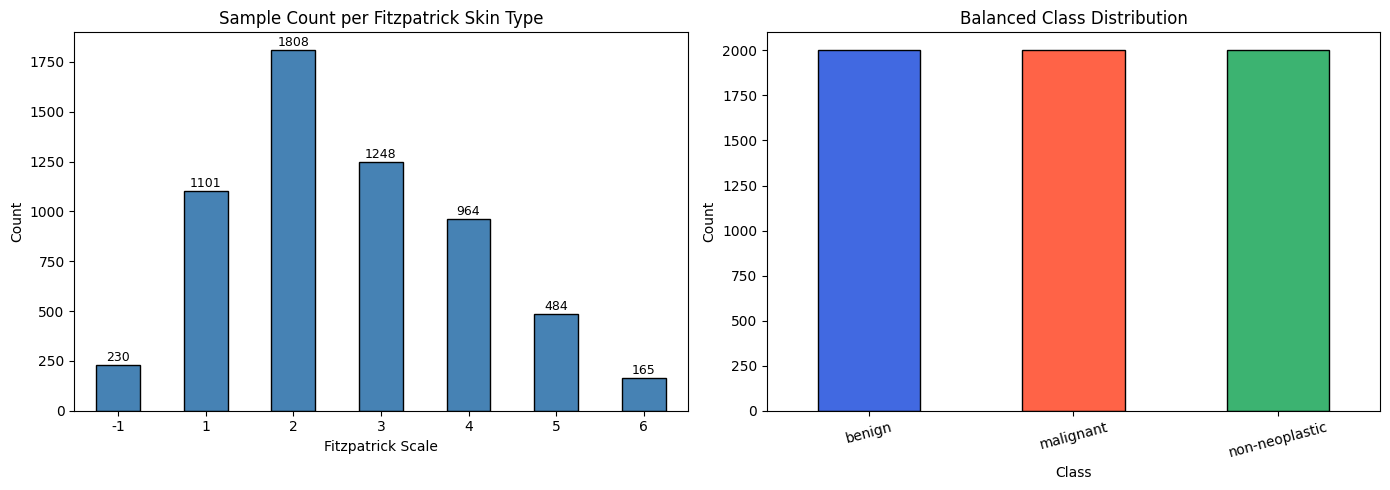

Plot saved.


In [8]:
# ── Balanced sampling: same number of images per class ───────────────────────
# This prevents training bias toward the dominant non-neoplastic class.

balanced_parts = []
for cls in CLASSES:
    cls_df = df[df["three_partition_label"] == cls]
    n = min(len(cls_df), SAMPLES_PER_CLASS)
    sampled = cls_df.sample(n=n, random_state=RANDOM_SEED)
    balanced_parts.append(sampled)
    print(f"  {cls:20s}: {len(cls_df):5d} available -> {n:5d} sampled")

df_balanced = pd.concat(balanced_parts).reset_index(drop=True)
print(f"\nTotal balanced dataset : {len(df_balanced)} images")

# ── Encode labels ─────────────────────────────────────────────────────────────
label2idx = {cls: i for i, cls in enumerate(CLASSES)}
idx2label = {i: cls for cls, i in label2idx.items()}
df_balanced["label"] = df_balanced["three_partition_label"].map(label2idx)

# ── Normalise Fitzpatrick scale column ────────────────────────────────────────
# Some datasets use 'fitzpatrick_scale', others 'fitzpatrick'; handle both.
fst_col = "fitzpatrick_scale" if "fitzpatrick_scale" in df_balanced.columns else "fitzpatrick"
df_balanced["fst"] = pd.to_numeric(df_balanced[fst_col], errors="coerce")

# ── Show per-skin-type sample counts ──────────────────────────────────────────
print("\nSample counts by Fitzpatrick skin type (in balanced dataset):")
fst_counts = df_balanced["fst"].value_counts().sort_index()
print(fst_counts.to_string())

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fst_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("Sample Count per Fitzpatrick Skin Type")
axes[0].set_xlabel("Fitzpatrick Scale")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 str(int(bar.get_height())), ha="center", va="bottom", fontsize=9)

df_balanced["three_partition_label"].value_counts().plot(kind="bar", ax=axes[1],
    color=["royalblue", "tomato", "mediumseagreen"], edgecolor="black")
axes[1].set_title("Balanced Class Distribution")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/01_data_distribution.png", dpi=150)
plt.show()
print("Plot saved.")

---
## 3. Train / Val / Test Split

In [9]:
test_ratio = 1.0 - TRAIN_RATIO - VAL_RATIO

train_df, temp_df = train_test_split(
    df_balanced, test_size=(1.0 - TRAIN_RATIO),
    random_state=RANDOM_SEED, stratify=df_balanced["label"]
)
val_df, test_df = train_test_split(
    temp_df, test_size=test_ratio / (VAL_RATIO + test_ratio),
    random_state=RANDOM_SEED, stratify=temp_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train : {len(train_df)} ({len(train_df)/len(df_balanced)*100:.1f}%)")
print(f"Val   : {len(val_df)}   ({len(val_df)/len(df_balanced)*100:.1f}%)")
print(f"Test  : {len(test_df)}  ({len(test_df)/len(df_balanced)*100:.1f}%)")
print("\nLabel distribution in test set:")
print(test_df["three_partition_label"].value_counts())

Train : 4199 (70.0%)
Val   : 900   (15.0%)
Test  : 901  (15.0%)

Label distribution in test set:
three_partition_label
non-neoplastic    301
malignant         300
benign            300
Name: count, dtype: int64


---
## 4. Transforms

In [10]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

# ── No-augmentation transforms (used for val, test, and baseline experiment) ──
val_transforms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE,
                  border_mode=cv2.BORDER_CONSTANT, fill=0),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# ── Augmented transforms (used for training in the augmented experiment) ───────
train_transforms = A.Compose([
    A.LongestMaxSize(max_size=IMG_SIZE),
    A.PadIfNeeded(min_height=IMG_SIZE, min_width=IMG_SIZE,
                  border_mode=cv2.BORDER_CONSTANT, fill=0),
    # Geometric augmentations well-suited for skin lesion images
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Rotate(limit=30, p=0.6),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=15, p=0.5),
    # Color augmentations (moderate to preserve diagnostic information)
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05, p=0.5),
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
    # Noise and blur
    A.GaussNoise(var_limit=(10.0, 30.0), p=0.3),
    A.MotionBlur(blur_limit=3, p=0.2),
    # CoarseDropout simulates occlusion / hair
    A.CoarseDropout(max_holes=8, max_height=16, max_width=16, fill_value=0, p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

print("Transforms defined.")

Transforms defined.


---
## 5. Dataset and DataLoaders

In [11]:
class FitzpatrickDataset(Dataset):
    """
    PyTorch Dataset for the Fitzpatrick17k data.
    Returns (image_tensor, label, fitzpatrick_scale) for each sample.
    """
    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = str(row["path"])
        label    = int(row["label"])
        fst      = float(row["fst"]) if not pd.isna(row["fst"]) else -1.0

        image = cv2.imread(img_path)
        if image is None:
            # Return a blank image rather than crashing the DataLoader
            image = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
        else:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]

        return image, label, fst


def make_loaders(train_df, val_df, test_df,
                 train_transform, eval_transform,
                 batch_size: int, num_workers: int):
    """Build train / val / test DataLoaders with a WeightedRandomSampler on train."""
    train_dataset = FitzpatrickDataset(train_df, transform=train_transform)
    val_dataset   = FitzpatrickDataset(val_df,   transform=eval_transform)
    test_dataset  = FitzpatrickDataset(test_df,  transform=eval_transform)

    # Weighted sampler to ensure balanced mini-batches during training
    train_labels  = train_df["label"].values
    class_counts  = np.bincount(train_labels, minlength=NUM_CLASSES)
    class_weights = 1.0 / class_counts.astype(float)
    sample_wts    = class_weights[train_labels]
    sampler       = WeightedRandomSampler(sample_wts, len(sample_wts), replacement=True)

    train_loader = DataLoader(train_dataset, batch_size=batch_size,
                              sampler=sampler, num_workers=num_workers,
                              pin_memory=True, drop_last=True)
    val_loader   = DataLoader(val_dataset, batch_size=batch_size,
                              shuffle=False, num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_dataset, batch_size=batch_size,
                              shuffle=False, num_workers=num_workers, pin_memory=True)

    return train_loader, val_loader, test_loader


print("Dataset class and loader factory defined.")

Dataset class and loader factory defined.


---
## 6. Model Definitions

In [12]:
def build_resnet50(num_classes: int, pretrained: bool = True) -> nn.Module:
    """ResNet50 with a replaced classification head."""
    weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
    model = models.resnet50(weights=weights)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes)
    )
    return model


def build_densenet121(num_classes: int, pretrained: bool = True) -> nn.Module:
    """DenseNet121 with a replaced classification head."""
    weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.densenet121(weights=weights)
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes)
    )
    return model


def build_vit(num_classes: int, pretrained: bool = True) -> nn.Module:
    """Vision Transformer ViT-B/16 using timm, with a replaced head."""
    model = timm.create_model(
        "vit_base_patch16_224",
        pretrained=pretrained,
        num_classes=0,      # Remove default head; we add our own
        drop_rate=0.1,
        attn_drop_rate=0.0,
    )
    embed_dim = model.embed_dim  # 768 for ViT-B/16
    model.head = nn.Sequential(
        nn.LayerNorm(embed_dim),
        nn.Dropout(p=0.4),
        nn.Linear(embed_dim, num_classes)
    )
    return model


MODEL_BUILDERS = {
    "resnet50":    build_resnet50,
    "densenet121": build_densenet121,
    "vit":         build_vit,
}

# Quick sanity check: forward pass on a dummy batch
dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE)
for name, builder in MODEL_BUILDERS.items():
    m = builder(NUM_CLASSES, pretrained=False)
    out = m(dummy)
    print(f"  {name:15s} output shape: {tuple(out.shape)}")
del dummy, m
print("All model builders OK.")

  resnet50        output shape: (2, 3)
  densenet121     output shape: (2, 3)
  vit             output shape: (2, 3)
All model builders OK.


---
## 7. Focal Loss

In [13]:
class FocalLoss(nn.Module):
    """
    Multi-class Focal Loss (Lin et al. 2017).

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Parameters
    ----------
    gamma  : float  - focusing parameter. 0 => standard cross-entropy.
    alpha  : list or None - per-class weights (length = num_classes).
    reduction : str - 'mean' | 'sum' | 'none'.
    """
    def __init__(self, gamma: float = 2.0, alpha=None, reduction: str = "mean"):
        super().__init__()
        self.gamma = gamma
        self.reduction = reduction
        if alpha is not None:
            alpha = torch.tensor(alpha, dtype=torch.float32)
        self.register_buffer("alpha", alpha)

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        logits  : (N, C) raw output from the model
        targets : (N,)   ground truth class indices
        """
        log_probs = F.log_softmax(logits, dim=-1)      # (N, C)
        probs     = torch.exp(log_probs)               # (N, C)

        # Gather probabilities of the true class
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)   # (N,)
        pt     = probs.gather(1, targets.unsqueeze(1)).squeeze(1)        # (N,)

        focal_weight = (1.0 - pt) ** self.gamma
        loss = -focal_weight * log_pt

        if self.alpha is not None:
            alpha_t = self.alpha.to(targets.device)[targets]
            loss = alpha_t * loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        return loss


criterion = FocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA)
print(f"FocalLoss initialised: gamma={FOCAL_GAMMA}, alpha={FOCAL_ALPHA}")

FocalLoss initialised: gamma=2.0, alpha=None


---
## 8. Training and Evaluation Utilities

In [14]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds  = []
    all_labels = []
    all_probs  = []
    all_fst    = []
    for images, labels, fst in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        probs = F.softmax(outputs, dim=1)
        preds = probs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_fst.extend(fst.numpy())
    return {
        "loss": running_loss / total,
        "acc":  correct / total,
        "preds":  np.array(all_preds),
        "labels": np.array(all_labels),
        "probs":  np.array(all_probs),
        "fst":    np.array(all_fst),
    }


def train_model(
    model_name: str,
    train_loader, val_loader,
    num_epochs: int,
    device,
    pretrained: bool = True,
    save_suffix: str = ""
):
    """
    Full training loop for one model.
    Returns the trained model and the training history dict.
    """
    model     = MODEL_BUILDERS[model_name](NUM_CLASSES, pretrained=pretrained).to(device)
    optimizer = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = CosineAnnealingWarmRestarts(optimizer, T_0=T_0, T_mult=T_MULT, eta_min=ETA_MIN)
    loss_fn   = FocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc":  [], "val_acc":  [],
        "val_f1":     [], "lr":       []
    }
    best_val_f1  = -1.0
    best_weights = copy.deepcopy(model.state_dict())
    save_path    = f"{OUTPUT_DIR}/{model_name}{save_suffix}_best.pth"

    print(f"\n{'='*60}")
    print(f"Training: {model_name.upper()}{save_suffix}  |  epochs={num_epochs}")
    print(f"{'='*60}")

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()
        train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_res = evaluate(model, val_loader, loss_fn, device)

        val_f1 = f1_score(val_res["labels"], val_res["preds"],
                          average="macro", zero_division=0)
        current_lr = scheduler.get_last_lr()[0]
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_res["loss"])
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_res["acc"])
        history["val_f1"].append(val_f1)
        history["lr"].append(current_lr)

        if val_f1 > best_val_f1:
            best_val_f1  = val_f1
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_path)

        elapsed = time.time() - t0
        print(f"  Ep {epoch:03d}/{num_epochs:03d}  "
              f"train_loss={train_loss:.4f}  val_loss={val_res['loss']:.4f}  "
              f"val_acc={val_res['acc']:.4f}  val_F1={val_f1:.4f}  "
              f"lr={current_lr:.2e}  ({elapsed:.1f}s)")

    model.load_state_dict(best_weights)
    print(f"\nBest val macro-F1 = {best_val_f1:.4f}  |  Model saved to {save_path}")
    return model, history


print("Training utilities defined.")

Training utilities defined.


---
## 9. Train All Models (No Augmentation + Augmentation)

In [15]:
# ── Experiment A: No Augmentation ────────────────────────────────────────────
trained_no_aug = {}
history_no_aug = {}

if RUN_NO_AUG:
    train_loader_noaug, val_loader_noaug, test_loader_noaug = make_loaders(
        train_df, val_df, test_df,
        train_transform=val_transforms,   # No augmentation on training too
        eval_transform=val_transforms,
        batch_size=BATCH_SIZE, num_workers=NUM_WORKERS
    )
    for mname in MODEL_BUILDERS:
        m, h = train_model(
            mname, train_loader_noaug, val_loader_noaug,
            num_epochs=NUM_EPOCHS, device=DEVICE,
            pretrained=PRETRAINED, save_suffix="_noaug"
        )
        trained_no_aug[mname] = m
        history_no_aug[mname] = h
    print("\nExperiment A (No Augmentation) complete.")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 238MB/s]



Training: RESNET50_noaug  |  epochs=20
  Ep 001/020  train_loss=0.3391  val_loss=0.3490  val_acc=0.6222  val_F1=0.6236  lr=3.00e-04  (64.4s)
  Ep 002/020  train_loss=0.2096  val_loss=0.3861  val_acc=0.6433  val_F1=0.6449  lr=2.93e-04  (55.3s)
  Ep 003/020  train_loss=0.1505  val_loss=0.3589  val_acc=0.6667  val_F1=0.6683  lr=2.71e-04  (54.0s)
  Ep 004/020  train_loss=0.0898  val_loss=0.3890  val_acc=0.6378  val_F1=0.6399  lr=2.38e-04  (52.7s)
  Ep 005/020  train_loss=0.0547  val_loss=0.4386  val_acc=0.6578  val_F1=0.6534  lr=1.97e-04  (52.8s)
  Ep 006/020  train_loss=0.0385  val_loss=0.4183  val_acc=0.6956  val_F1=0.6959  lr=1.50e-04  (52.7s)
  Ep 007/020  train_loss=0.0166  val_loss=0.4233  val_acc=0.7089  val_F1=0.7074  lr=1.04e-04  (52.4s)
  Ep 008/020  train_loss=0.0077  val_loss=0.4449  val_acc=0.7133  val_F1=0.7130  lr=6.26e-05  (51.6s)
  Ep 009/020  train_loss=0.0049  val_loss=0.4462  val_acc=0.7089  val_F1=0.7081  lr=2.96e-05  (52.1s)
  Ep 010/020  train_loss=0.0026  val_loss=

100%|██████████| 30.8M/30.8M [00:00<00:00, 207MB/s]



Training: DENSENET121_noaug  |  epochs=20
  Ep 001/020  train_loss=0.4028  val_loss=0.4151  val_acc=0.5778  val_F1=0.5700  lr=3.00e-04  (52.6s)
  Ep 002/020  train_loss=0.2808  val_loss=0.3943  val_acc=0.5956  val_F1=0.5934  lr=2.93e-04  (52.2s)
  Ep 003/020  train_loss=0.2175  val_loss=0.3890  val_acc=0.6200  val_F1=0.6155  lr=2.71e-04  (52.7s)
  Ep 004/020  train_loss=0.1446  val_loss=0.3469  val_acc=0.6556  val_F1=0.6552  lr=2.38e-04  (52.9s)
  Ep 005/020  train_loss=0.0878  val_loss=0.4226  val_acc=0.6622  val_F1=0.6632  lr=1.97e-04  (52.3s)
  Ep 006/020  train_loss=0.0602  val_loss=0.3991  val_acc=0.6767  val_F1=0.6771  lr=1.50e-04  (52.6s)
  Ep 007/020  train_loss=0.0290  val_loss=0.4011  val_acc=0.6978  val_F1=0.6982  lr=1.04e-04  (51.8s)
  Ep 008/020  train_loss=0.0155  val_loss=0.4122  val_acc=0.7089  val_F1=0.7082  lr=6.26e-05  (52.9s)
  Ep 009/020  train_loss=0.0069  val_loss=0.4033  val_acc=0.7122  val_F1=0.7117  lr=2.96e-05  (53.4s)
  Ep 010/020  train_loss=0.0065  val_lo

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


Training: VIT_noaug  |  epochs=20
  Ep 001/020  train_loss=0.5813  val_loss=0.4884  val_acc=0.3400  val_F1=0.1994  lr=3.00e-04  (108.9s)
  Ep 002/020  train_loss=0.5073  val_loss=0.4844  val_acc=0.3767  val_F1=0.3421  lr=2.93e-04  (108.8s)
  Ep 003/020  train_loss=0.5034  val_loss=0.4842  val_acc=0.3811  val_F1=0.2833  lr=2.71e-04  (107.9s)
  Ep 004/020  train_loss=0.4932  val_loss=0.4869  val_acc=0.3356  val_F1=0.1910  lr=2.38e-04  (108.4s)
  Ep 005/020  train_loss=0.4792  val_loss=0.4790  val_acc=0.3967  val_F1=0.3047  lr=1.97e-04  (108.7s)
  Ep 006/020  train_loss=0.4511  val_loss=0.5054  val_acc=0.4078  val_F1=0.3268  lr=1.50e-04  (108.9s)
  Ep 007/020  train_loss=0.4123  val_loss=0.4932  val_acc=0.4322  val_F1=0.4340  lr=1.04e-04  (109.6s)
  Ep 008/020  train_loss=0.3507  val_loss=0.5440  val_acc=0.4244  val_F1=0.4204  lr=6.26e-05  (108.5s)
  Ep 009/020  train_loss=0.2830  val_loss=0.6761  val_acc=0.4467  val_F1=0.4446  lr=2.96e-05  (108.6s)
  Ep 010/020  train_loss=0.2145  val_l

In [16]:
# ── Experiment B: With Augmentation ──────────────────────────────────────────
trained_aug = {}
history_aug = {}

if RUN_AUG:
    train_loader_aug, val_loader_aug, test_loader_aug = make_loaders(
        train_df, val_df, test_df,
        train_transform=train_transforms,
        eval_transform=val_transforms,
        batch_size=BATCH_SIZE, num_workers=NUM_WORKERS
    )
    for mname in MODEL_BUILDERS:
        m, h = train_model(
            mname, train_loader_aug, val_loader_aug,
            num_epochs=NUM_EPOCHS, device=DEVICE,
            pretrained=PRETRAINED, save_suffix="_aug"
        )
        trained_aug[mname] = m
        history_aug[mname] = h
    print("\nExperiment B (With Augmentation) complete.")


Training: RESNET50_aug  |  epochs=20
  Ep 001/020  train_loss=0.4290  val_loss=0.3979  val_acc=0.5756  val_F1=0.5728  lr=3.00e-04  (60.9s)
  Ep 002/020  train_loss=0.3855  val_loss=0.4181  val_acc=0.5656  val_F1=0.5612  lr=2.93e-04  (61.6s)
  Ep 003/020  train_loss=0.3646  val_loss=0.3510  val_acc=0.6144  val_F1=0.6106  lr=2.71e-04  (60.7s)
  Ep 004/020  train_loss=0.3471  val_loss=0.3251  val_acc=0.6589  val_F1=0.6592  lr=2.38e-04  (61.9s)
  Ep 005/020  train_loss=0.3098  val_loss=0.3343  val_acc=0.6444  val_F1=0.6414  lr=1.97e-04  (62.5s)
  Ep 006/020  train_loss=0.2832  val_loss=0.3652  val_acc=0.6422  val_F1=0.6428  lr=1.50e-04  (62.1s)
  Ep 007/020  train_loss=0.2725  val_loss=0.3207  val_acc=0.6844  val_F1=0.6867  lr=1.04e-04  (62.2s)
  Ep 008/020  train_loss=0.2425  val_loss=0.3084  val_acc=0.7000  val_F1=0.6992  lr=6.26e-05  (61.8s)
  Ep 009/020  train_loss=0.2204  val_loss=0.2995  val_acc=0.7111  val_F1=0.7122  lr=2.96e-05  (60.9s)
  Ep 010/020  train_loss=0.2137  val_loss=0.


Training: VIT_aug  |  epochs=20
  Ep 001/020  train_loss=0.6161  val_loss=0.4946  val_acc=0.3367  val_F1=0.1739  lr=3.00e-04  (117.4s)
  Ep 002/020  train_loss=0.5095  val_loss=0.4913  val_acc=0.3533  val_F1=0.2714  lr=2.93e-04  (118.2s)
  Ep 003/020  train_loss=0.5047  val_loss=0.4846  val_acc=0.3589  val_F1=0.2936  lr=2.71e-04  (117.8s)
  Ep 004/020  train_loss=0.4973  val_loss=0.4847  val_acc=0.3511  val_F1=0.2510  lr=2.38e-04  (117.8s)
  Ep 005/020  train_loss=0.4888  val_loss=0.4914  val_acc=0.3744  val_F1=0.2699  lr=1.97e-04  (117.7s)
  Ep 006/020  train_loss=0.4876  val_loss=0.4722  val_acc=0.4311  val_F1=0.4190  lr=1.50e-04  (117.8s)
  Ep 007/020  train_loss=0.4810  val_loss=0.4701  val_acc=0.4278  val_F1=0.3731  lr=1.04e-04  (117.3s)
  Ep 008/020  train_loss=0.4635  val_loss=0.4602  val_acc=0.4433  val_F1=0.4412  lr=6.26e-05  (118.4s)
  Ep 009/020  train_loss=0.4551  val_loss=0.4572  val_acc=0.4433  val_F1=0.4403  lr=2.96e-05  (117.3s)
  Ep 010/020  train_loss=0.4532  val_los

---
## 10. Training Curves: Augmentation vs No Augmentation

In [1]:
def plot_training_curves(history_dict_a: dict, history_dict_b: dict,
                         label_a: str = "No Aug", label_b: str = "Aug",
                         save_prefix: str = ""):
    """Plot and save training curves for each model side-by-side."""
    n_models = len(history_dict_b)
    fig, axes = plt.subplots(n_models, 3, figsize=(18, 5 * n_models))
    if n_models == 1:
        axes = axes[np.newaxis, :]

    for row_idx, mname in enumerate(MODEL_BUILDERS):
        ha = history_dict_a.get(mname, {})
        hb = history_dict_b.get(mname, {})
        epochs = range(1, len(hb.get("train_loss", [])) + 1)

        # Loss
        ax = axes[row_idx, 0]
        if ha:
            ax.plot(range(1, len(ha["val_loss"])+1), ha["val_loss"],
                    linestyle="--", label=f"Val Loss ({label_a})")
        if hb:
            ax.plot(epochs, hb["val_loss"], label=f"Val Loss ({label_b})")
        ax.set_title(f"{mname.upper()} - Validation Loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Focal Loss")
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Accuracy
        ax = axes[row_idx, 1]
        if ha:
            ax.plot(range(1, len(ha["val_acc"])+1), ha["val_acc"],
                    linestyle="--", label=f"Val Acc ({label_a})")
        if hb:
            ax.plot(epochs, hb["val_acc"], label=f"Val Acc ({label_b})")
        ax.set_title(f"{mname.upper()} - Validation Accuracy")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.legend()
        ax.grid(True, alpha=0.3)

        # Macro F1
        ax = axes[row_idx, 2]
        if ha:
            ax.plot(range(1, len(ha["val_f1"])+1), ha["val_f1"],
                    linestyle="--", label=f"Val F1 ({label_a})")
        if hb:
            ax.plot(epochs, hb["val_f1"], label=f"Val F1 ({label_b})")
        ax.set_title(f"{mname.upper()} - Validation Macro-F1")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Macro F1")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle(f"Training Curves: {label_a} vs {label_b}", fontsize=15, y=1.01)
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/{save_prefix}training_curves.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")


plot_training_curves(history_no_aug, history_aug,
                     label_a="No Aug", label_b="Aug",
                     save_prefix="02_")

NameError: name 'history_no_aug' is not defined

---
## 11. Individual Model Evaluation on Test Set


--- RESNET50 [no_aug] ---
                precision    recall  f1-score   support

        benign       0.67      0.70      0.68       300
     malignant       0.79      0.79      0.79       300
non-neoplastic       0.73      0.71      0.72       301

      accuracy                           0.73       901
     macro avg       0.73      0.73      0.73       901
  weighted avg       0.73      0.73      0.73       901



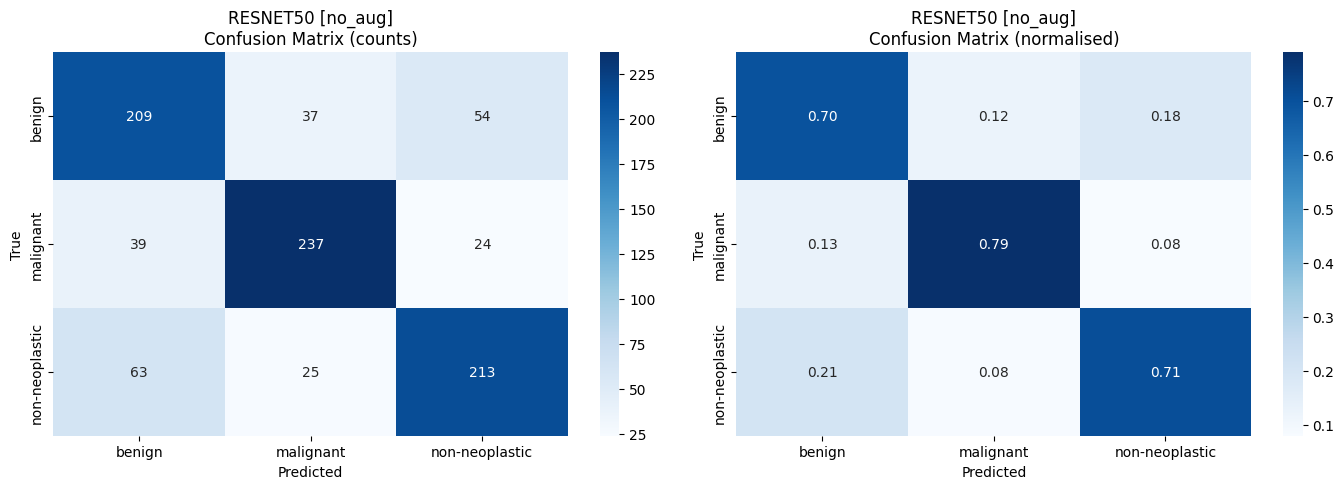

Saved: /kaggle/working//03_resnet50_no_aug_confusion_matrix.png

--- DENSENET121 [no_aug] ---
                precision    recall  f1-score   support

        benign       0.69      0.73      0.71       300
     malignant       0.80      0.79      0.79       300
non-neoplastic       0.75      0.71      0.73       301

      accuracy                           0.74       901
     macro avg       0.75      0.74      0.74       901
  weighted avg       0.75      0.74      0.74       901



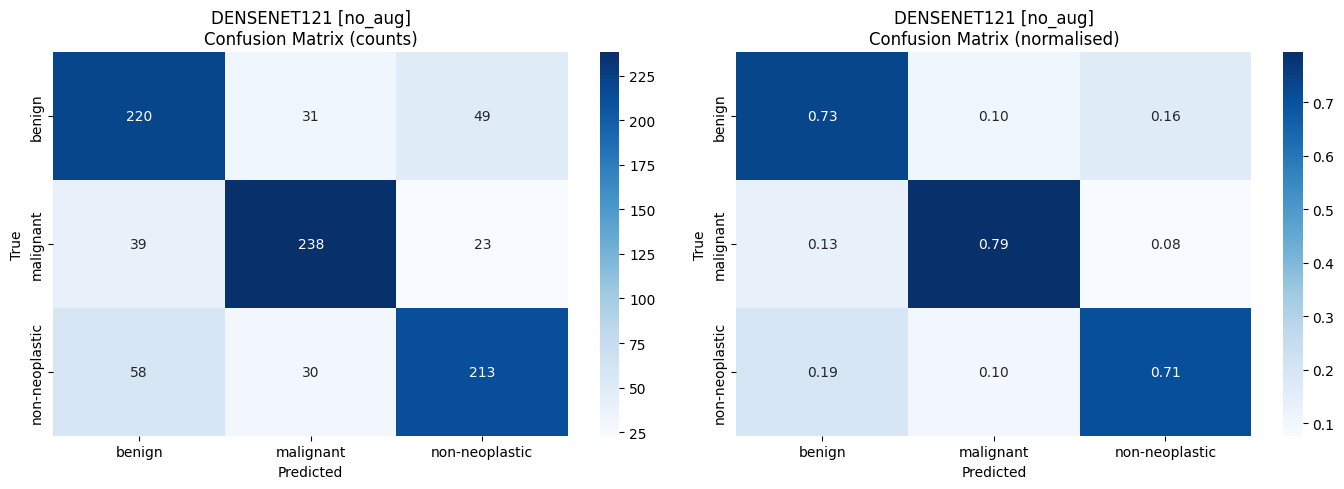

Saved: /kaggle/working//03_densenet121_no_aug_confusion_matrix.png

--- VIT [no_aug] ---
                precision    recall  f1-score   support

        benign       0.37      0.44      0.40       300
     malignant       0.55      0.46      0.50       300
non-neoplastic       0.48      0.47      0.48       301

      accuracy                           0.46       901
     macro avg       0.47      0.46      0.46       901
  weighted avg       0.47      0.46      0.46       901



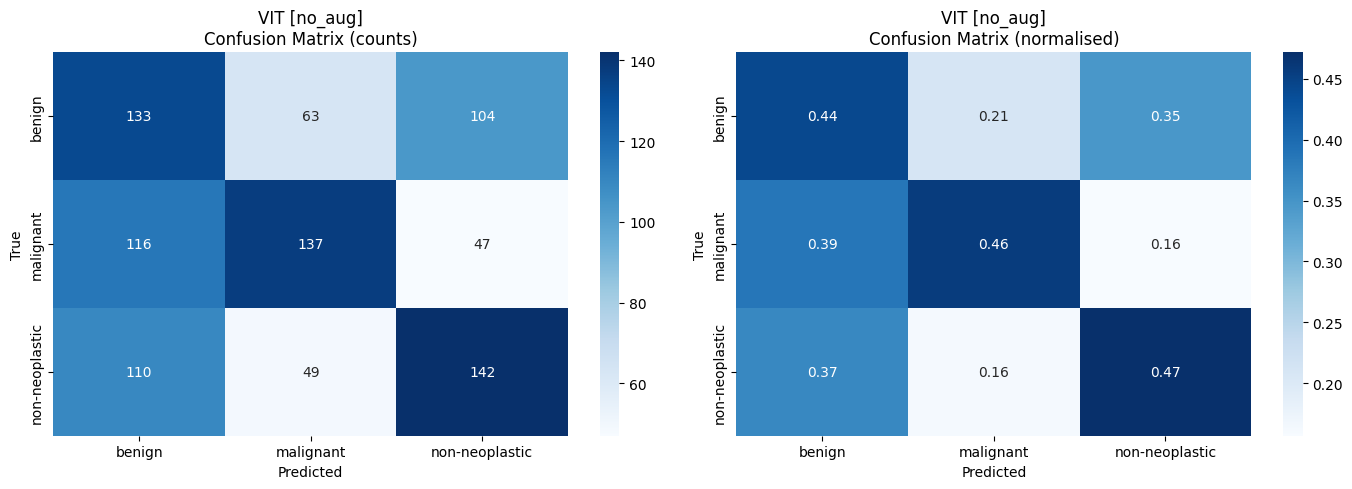

Saved: /kaggle/working//03_vit_no_aug_confusion_matrix.png

--- RESNET50 [aug] ---
                precision    recall  f1-score   support

        benign       0.67      0.71      0.69       300
     malignant       0.82      0.72      0.77       300
non-neoplastic       0.68      0.73      0.71       301

      accuracy                           0.72       901
     macro avg       0.72      0.72      0.72       901
  weighted avg       0.72      0.72      0.72       901



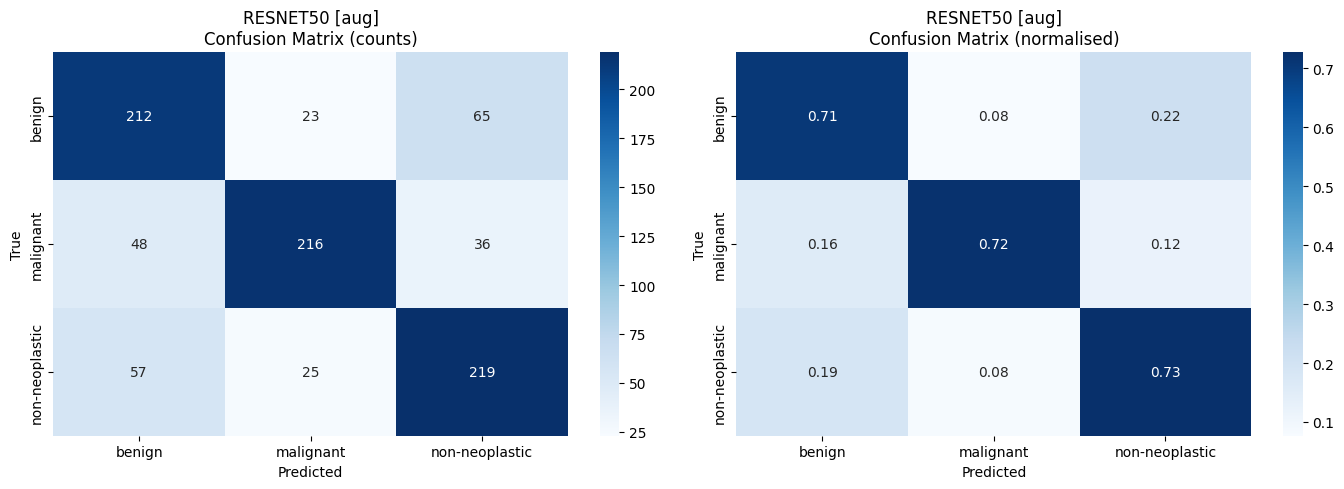

Saved: /kaggle/working//03_resnet50_aug_confusion_matrix.png

--- DENSENET121 [aug] ---
                precision    recall  f1-score   support

        benign       0.65      0.65      0.65       300
     malignant       0.77      0.81      0.79       300
non-neoplastic       0.73      0.68      0.70       301

      accuracy                           0.71       901
     macro avg       0.71      0.71      0.71       901
  weighted avg       0.71      0.71      0.71       901



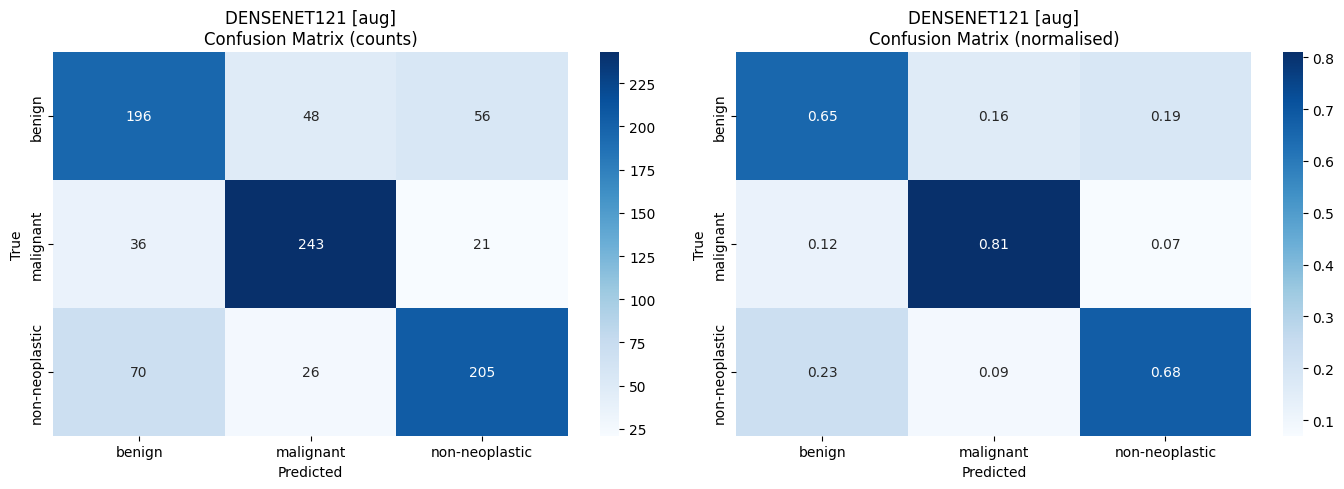

Saved: /kaggle/working//03_densenet121_aug_confusion_matrix.png

--- VIT [aug] ---
                precision    recall  f1-score   support

        benign       0.47      0.37      0.42       300
     malignant       0.56      0.57      0.56       300
non-neoplastic       0.54      0.65      0.59       301

      accuracy                           0.53       901
     macro avg       0.53      0.53      0.52       901
  weighted avg       0.53      0.53      0.52       901



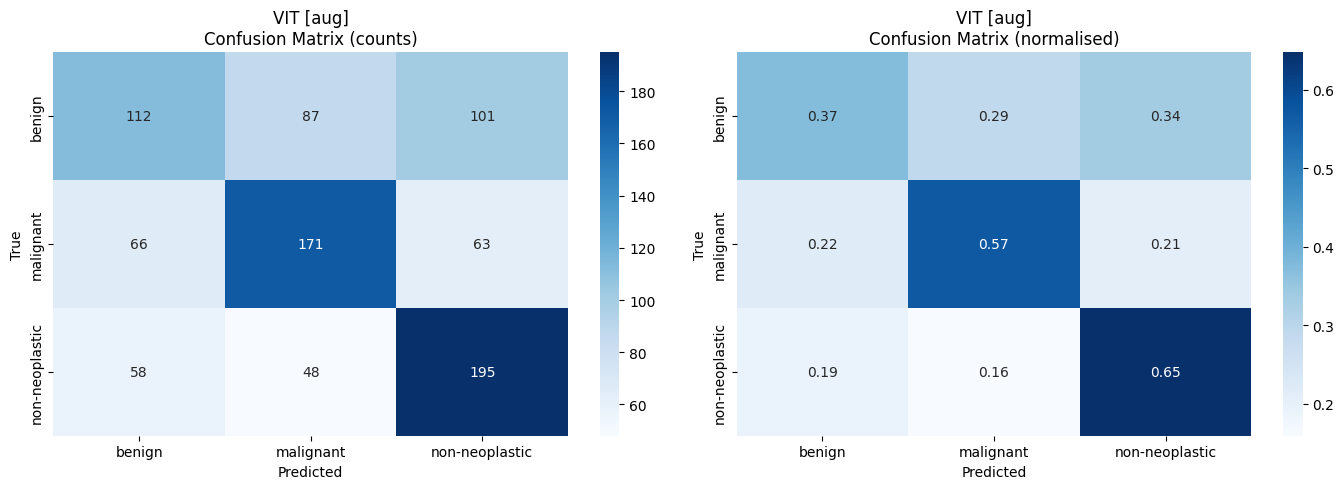

Saved: /kaggle/working//03_vit_aug_confusion_matrix.png


In [17]:
def full_classification_report(y_true, y_pred, title: str = "", save_prefix: str = ""):
    """Print and plot a full classification report and confusion matrix."""
    report_dict = classification_report(
        y_true, y_pred, target_names=CLASSES,
        output_dict=True, zero_division=0
    )
    report_str = classification_report(
        y_true, y_pred, target_names=CLASSES, zero_division=0
    )
    print(f"\n--- {title} ---")
    print(report_str)

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[0])
    axes[0].set_title(f"{title}\nConfusion Matrix (counts)")
    axes[0].set_ylabel("True")
    axes[0].set_xlabel("Predicted")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=axes[1])
    axes[1].set_title(f"{title}\nConfusion Matrix (normalised)")
    axes[1].set_ylabel("True")
    axes[1].set_xlabel("Predicted")

    plt.tight_layout()
    path = f"{OUTPUT_DIR}/{save_prefix}confusion_matrix.png"
    plt.savefig(path, dpi=150)
    plt.show()
    print(f"Saved: {path}")
    return report_dict


# Collect test-set predictions from each model in both experiments
test_results = {}   # test_results["aug"][mname] = evaluate() output dict
report_store = {}   # report_store["aug"][mname] = classification report dict

eval_loss_fn = FocalLoss(gamma=FOCAL_GAMMA, alpha=FOCAL_ALPHA)

for exp_name, trained_dict in [("no_aug", trained_no_aug), ("aug", trained_aug)]:
    if not trained_dict:
        continue
    test_results[exp_name] = {}
    report_store[exp_name] = {}
    # Use the correct test loader (they share the same eval transform, so either is fine)
    tloader = test_loader_noaug if exp_name == "no_aug" else test_loader_aug
    for mname, model in trained_dict.items():
        res = evaluate(model, tloader, eval_loss_fn, DEVICE)
        test_results[exp_name][mname] = res
        report = full_classification_report(
            res["labels"], res["preds"],
            title=f"{mname.upper()} [{exp_name}]",
            save_prefix=f"03_{mname}_{exp_name}_"
        )
        report_store[exp_name][mname] = report


Individual Model Performance Summary:
Experiment       Model  Precision  Recall  F1-score  Accuracy
       aug    resnet50     0.7238  0.7181    0.7195    0.7181
       aug densenet121     0.7142  0.7148    0.7140    0.7148
       aug         vit     0.5255  0.5304    0.5244    0.5305
    no_aug densenet121     0.7458  0.7448    0.7449    0.7447
    no_aug    resnet50     0.7322  0.7314    0.7317    0.7314
    no_aug         vit     0.4684  0.4573    0.4603    0.4573
Saved: /kaggle/working//04_individual_model_summary.csv


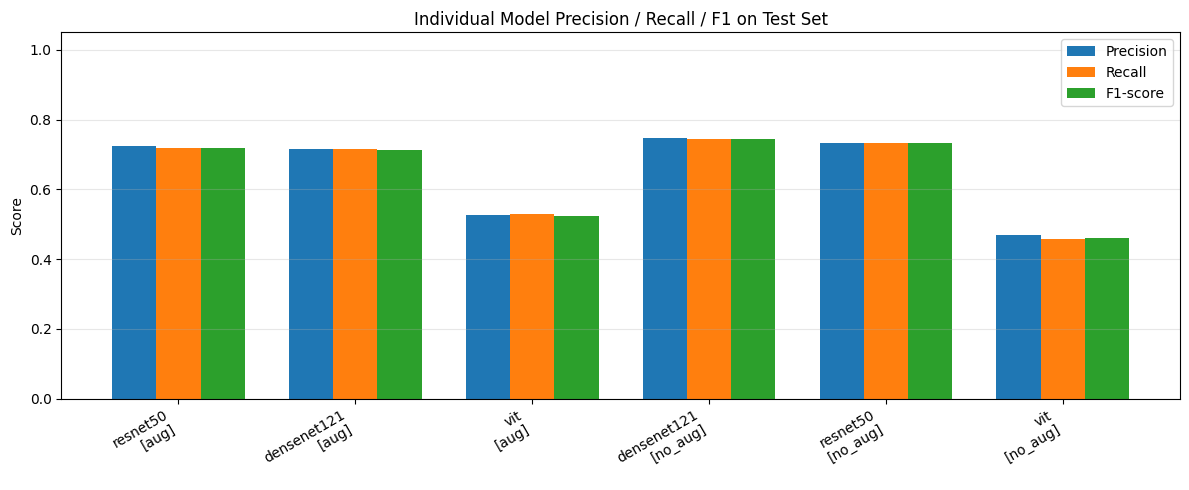

In [18]:
# ── Summary table: all models and both experiments ────────────────────────────
rows = []
for exp_name, reports in report_store.items():
    for mname, rpt in reports.items():
        rows.append({
            "Experiment":  exp_name,
            "Model":       mname,
            "Precision":   round(rpt["macro avg"]["precision"], 4),
            "Recall":      round(rpt["macro avg"]["recall"], 4),
            "F1-score":    round(rpt["macro avg"]["f1-score"], 4),
            "Accuracy":    round(rpt["accuracy"], 4),
        })

summary_df = pd.DataFrame(rows).sort_values(["Experiment", "F1-score"], ascending=[True, False])
print("\nIndividual Model Performance Summary:")
print(summary_df.to_string(index=False))
summary_df.to_csv(f"{OUTPUT_DIR}/04_individual_model_summary.csv", index=False)
print(f"Saved: {OUTPUT_DIR}/04_individual_model_summary.csv")

# Bar plot
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(summary_df))
width = 0.25
ax.bar(x - width, summary_df["Precision"], width, label="Precision")
ax.bar(x,          summary_df["Recall"],    width, label="Recall")
ax.bar(x + width,  summary_df["F1-score"],  width, label="F1-score")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r['Model']}\n[{r['Experiment']}]" for _, r in summary_df.iterrows()],
    rotation=30, ha="right"
)
ax.set_ylabel("Score")
ax.set_title("Individual Model Precision / Recall / F1 on Test Set")
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/04_model_comparison_bar.png", dpi=150)
plt.show()

---
## 12. Weighted Ensemble with Optimal Weight Search


Searching optimal ensemble weights for [no_aug] ...
  Optimal weights: resnet50=0.20, densenet121=0.50, vit=0.30
  Validation macro-F1 with optimal weights: 0.7405

--- Ensemble [no_aug] (optimal weights) ---
                precision    recall  f1-score   support

        benign       0.68      0.74      0.71       300
     malignant       0.81      0.78      0.80       300
non-neoplastic       0.74      0.71      0.73       301

      accuracy                           0.74       901
     macro avg       0.75      0.74      0.74       901
  weighted avg       0.75      0.74      0.74       901



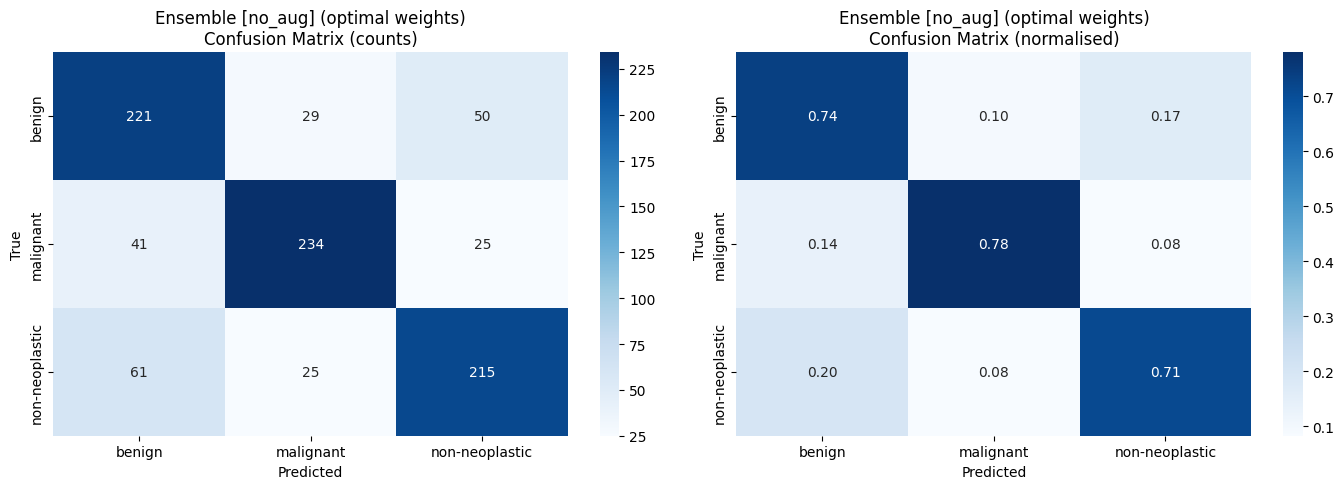

Saved: /kaggle/working//05_ensemble_no_aug_confusion_matrix.png

Searching optimal ensemble weights for [aug] ...
  Optimal weights: resnet50=0.50, densenet121=0.50, vit=0.00
  Validation macro-F1 with optimal weights: 0.7430

--- Ensemble [aug] (optimal weights) ---
                precision    recall  f1-score   support

        benign       0.67      0.69      0.68       300
     malignant       0.79      0.77      0.78       300
non-neoplastic       0.72      0.71      0.71       301

      accuracy                           0.72       901
     macro avg       0.72      0.72      0.72       901
  weighted avg       0.72      0.72      0.72       901



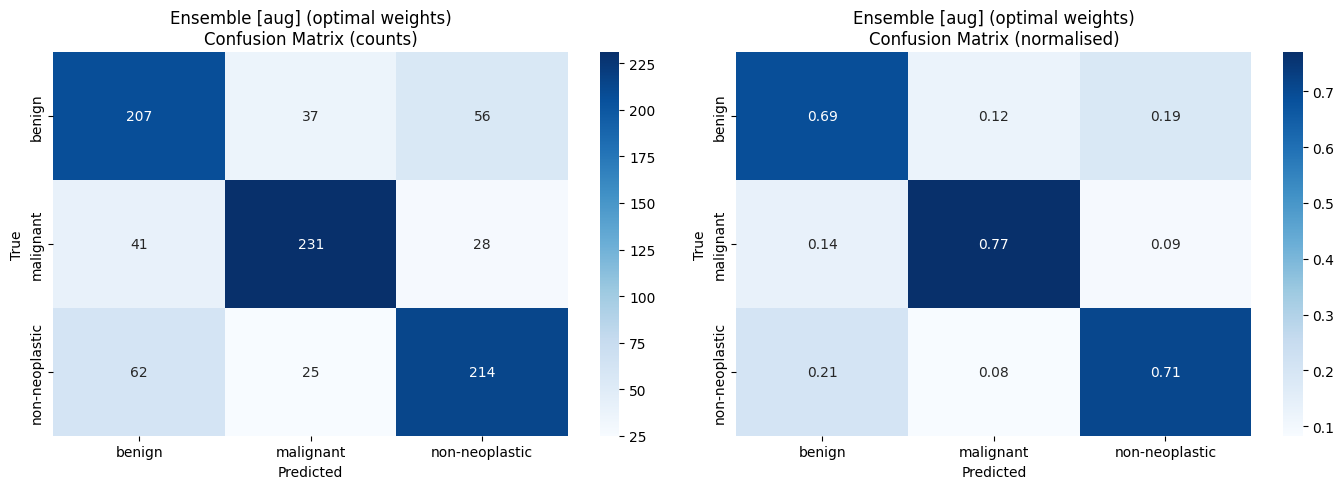

Saved: /kaggle/working//05_ensemble_aug_confusion_matrix.png


In [19]:
def ensemble_predict(probs_dict: dict, weights: np.ndarray) -> np.ndarray:
    """
    Compute weighted-average softmax probabilities.

    probs_dict : {model_name: (N, C) array of softmax probabilities}
    weights    : 1-D array of length len(probs_dict), sums to 1
    Returns    : (N, C) weighted average probabilities
    """
    stacked = np.stack(list(probs_dict.values()), axis=0)   # (M, N, C)
    w       = weights[:, None, None]                         # (M, 1, 1)
    return (stacked * w).sum(axis=0)                         # (N, C)


def grid_search_weights(probs_dict: dict, true_labels: np.ndarray,
                         n_steps: int = 11) -> np.ndarray:
    """
    Exhaustive grid search over ensemble weights to maximise macro-F1.
    Each weight varies in [0, 1] with step = 1/(n_steps-1).
    Combinations that do not sum to 1 are skipped.
    """
    n_models = len(probs_dict)
    grid     = np.linspace(0, 1, n_steps)
    best_f1  = -1.0
    best_w   = np.ones(n_models) / n_models

    for combo in product(grid, repeat=n_models):
        combo = np.array(combo)
        if not np.isclose(combo.sum(), 1.0, atol=1e-6):
            continue
        avg_probs = ensemble_predict(probs_dict, combo)
        preds     = avg_probs.argmax(axis=1)
        f1        = f1_score(true_labels, preds, average="macro", zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_w  = combo.copy()

    return best_w, best_f1


# Run ensemble on validation set to find optimal weights, then evaluate on test set
ensemble_results = {}

for exp_name, trained_dict in [("no_aug", trained_no_aug), ("aug", trained_aug)]:
    if not trained_dict:
        continue

    vloader = val_loader_noaug if exp_name == "no_aug" else val_loader_aug
    tloader = test_loader_noaug if exp_name == "no_aug" else test_loader_aug

    # Collect val probabilities
    val_probs  = {}
    val_labels = None
    for mname, model in trained_dict.items():
        res = evaluate(model, vloader, eval_loss_fn, DEVICE)
        val_probs[mname] = res["probs"]
        val_labels = res["labels"]

    # Find optimal weights
    print(f"\nSearching optimal ensemble weights for [{exp_name}] ...")
    opt_weights, val_f1 = grid_search_weights(val_probs, val_labels, n_steps=GRID_STEPS)
    w_str = ", ".join(f"{n}={w:.2f}" for n, w in zip(trained_dict.keys(), opt_weights))
    print(f"  Optimal weights: {w_str}")
    print(f"  Validation macro-F1 with optimal weights: {val_f1:.4f}")

    # Evaluate on test set with optimal weights
    test_probs  = {}
    test_labels = None
    test_fst    = None
    for mname, model in trained_dict.items():
        res = evaluate(model, tloader, eval_loss_fn, DEVICE)
        test_probs[mname] = res["probs"]
        test_labels = res["labels"]
        test_fst    = res["fst"]

    avg_probs   = ensemble_predict(test_probs, opt_weights)
    ens_preds   = avg_probs.argmax(axis=1)

    ensemble_results[exp_name] = {
        "opt_weights": {n: float(w) for n, w in zip(trained_dict.keys(), opt_weights)},
        "test_probs":  avg_probs,
        "test_preds":  ens_preds,
        "test_labels": test_labels,
        "test_fst":    test_fst,
    }

    # Print and plot
    full_classification_report(
        test_labels, ens_preds,
        title=f"Ensemble [{exp_name}] (optimal weights)",
        save_prefix=f"05_ensemble_{exp_name}_"
    )

In [20]:
# ── Numerical summary of ensemble results ────────────────────────────────────
for exp_name, res in ensemble_results.items():
    y_true = res["test_labels"]
    y_pred = res["test_preds"]
    p = precision_score(y_true, y_pred, average="macro", zero_division=0)
    r = recall_score(y_true,    y_pred, average="macro", zero_division=0)
    f = f1_score(y_true,        y_pred, average="macro", zero_division=0)
    print(f"\nEnsemble [{exp_name}]")
    print(f"  Optimal weights : {res['opt_weights']}")
    print(f"  Macro Precision : {p:.4f}")
    print(f"  Macro Recall    : {r:.4f}")
    print(f"  Macro F1-score  : {f:.4f}")


Ensemble [no_aug]
  Optimal weights : {'resnet50': 0.2, 'densenet121': 0.5, 'vit': 0.30000000000000004}
  Macro Precision : 0.7460
  Macro Recall    : 0.7437
  Macro F1-score  : 0.7443

Ensemble [aug]
  Optimal weights : {'resnet50': 0.5, 'densenet121': 0.5, 'vit': 0.0}
  Macro Precision : 0.7248
  Macro Recall    : 0.7237
  Macro F1-score  : 0.7241


---
## 13. Fairness Analysis: Performance per Fitzpatrick Skin Type


--- Fairness Report: Ensemble [no_aug] ---
  FST       N   Precision    Recall        F1
  FST 1  N=  160  Precision=0.6979  Recall=0.6887  F1=0.6893
  FST 2  N=  271  Precision=0.7336  Recall=0.7395  F1=0.7350
  FST 3  N=  189  Precision=0.7622  Recall=0.7631  F1=0.7616
  FST 4  N=  139  Precision=0.7575  Recall=0.7528  F1=0.7537
  FST 5  N=   76  Precision=0.7627  Recall=0.7774  F1=0.7690
  FST 6  N=   27  Precision=0.7361  Recall=0.7190  F1=0.7192


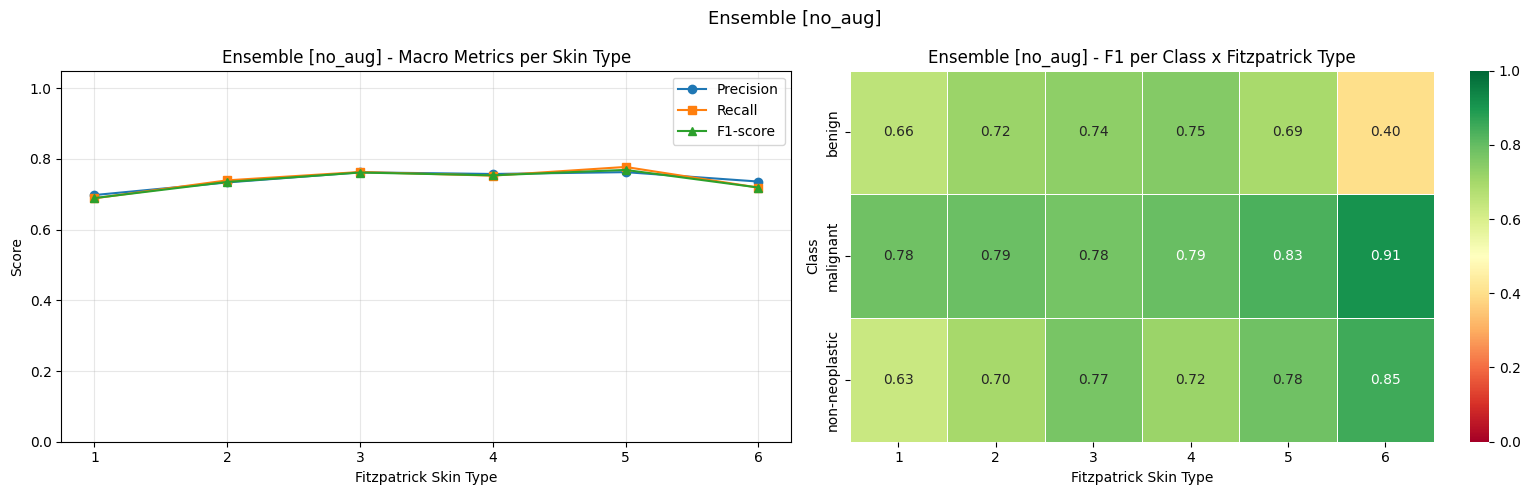

Saved: /kaggle/working//06_ensemble_no_aug_fairness.png

--- Fairness Report: Ensemble [aug] ---
  FST       N   Precision    Recall        F1
  FST 1  N=  160  Precision=0.6953  Recall=0.6989  F1=0.6948
  FST 2  N=  271  Precision=0.6970  Recall=0.7068  F1=0.6987
  FST 3  N=  189  Precision=0.7186  Recall=0.7193  F1=0.7182
  FST 4  N=  139  Precision=0.7997  Recall=0.7819  F1=0.7860
  FST 5  N=   76  Precision=0.7812  Recall=0.7902  F1=0.7851
  FST 6  N=   27  Precision=0.6830  Recall=0.6830  F1=0.6830


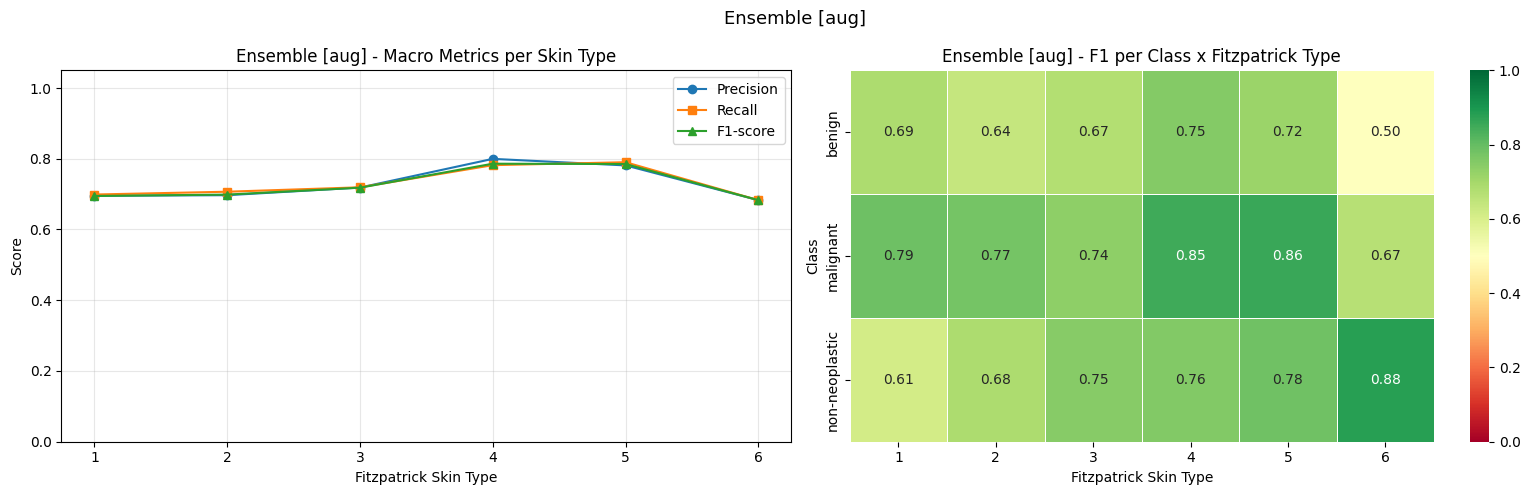

Saved: /kaggle/working//06_ensemble_aug_fairness.png

--- Fairness Report: RESNET50 [aug] ---
  FST       N   Precision    Recall        F1
  FST 1  N=  160  Precision=0.6682  Recall=0.6695  F1=0.6617
  FST 2  N=  271  Precision=0.7050  Recall=0.7094  F1=0.7042
  FST 3  N=  189  Precision=0.7134  Recall=0.7146  F1=0.7136
  FST 4  N=  139  Precision=0.7724  Recall=0.7424  F1=0.7521
  FST 5  N=   76  Precision=0.8249  Recall=0.8300  F1=0.8268
  FST 6  N=   27  Precision=0.8816  Recall=0.8056  F1=0.8315


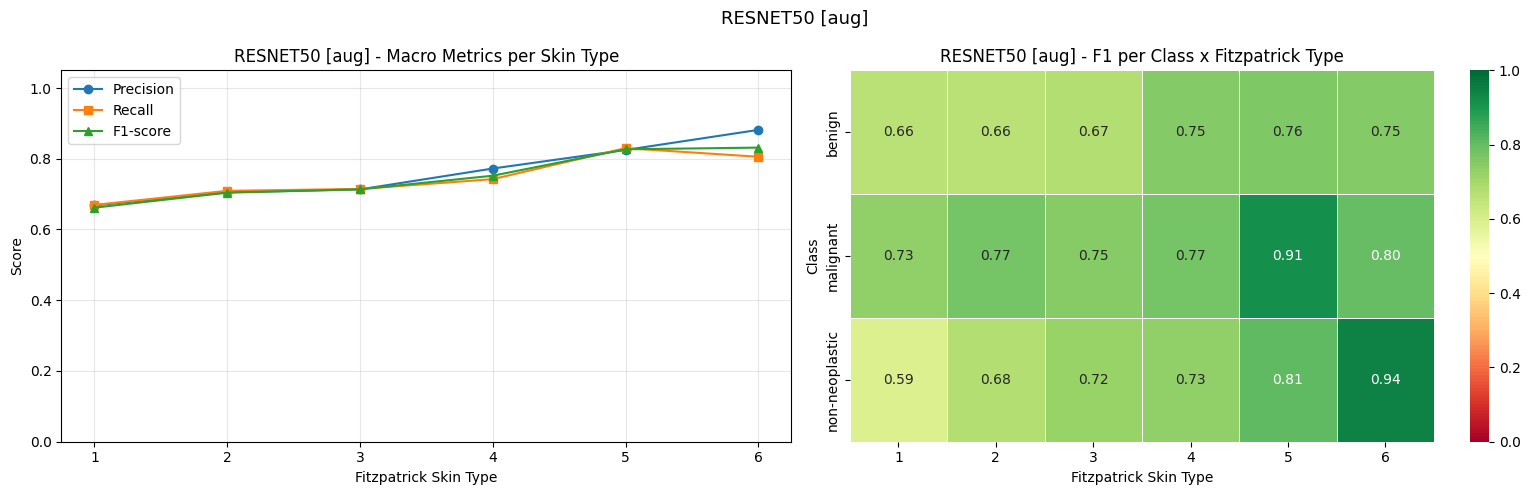

Saved: /kaggle/working//06_resnet50_aug_fairness.png

--- Fairness Report: DENSENET121 [aug] ---
  FST       N   Precision    Recall        F1
  FST 1  N=  160  Precision=0.6482  Recall=0.6502  F1=0.6481
  FST 2  N=  271  Precision=0.6734  Recall=0.6811  F1=0.6745
  FST 3  N=  189  Precision=0.7118  Recall=0.7113  F1=0.7103
  FST 4  N=  139  Precision=0.7924  Recall=0.8004  F1=0.7931
  FST 5  N=   76  Precision=0.7903  Recall=0.8058  F1=0.7946
  FST 6  N=   27  Precision=0.6825  Recall=0.7190  F1=0.6962


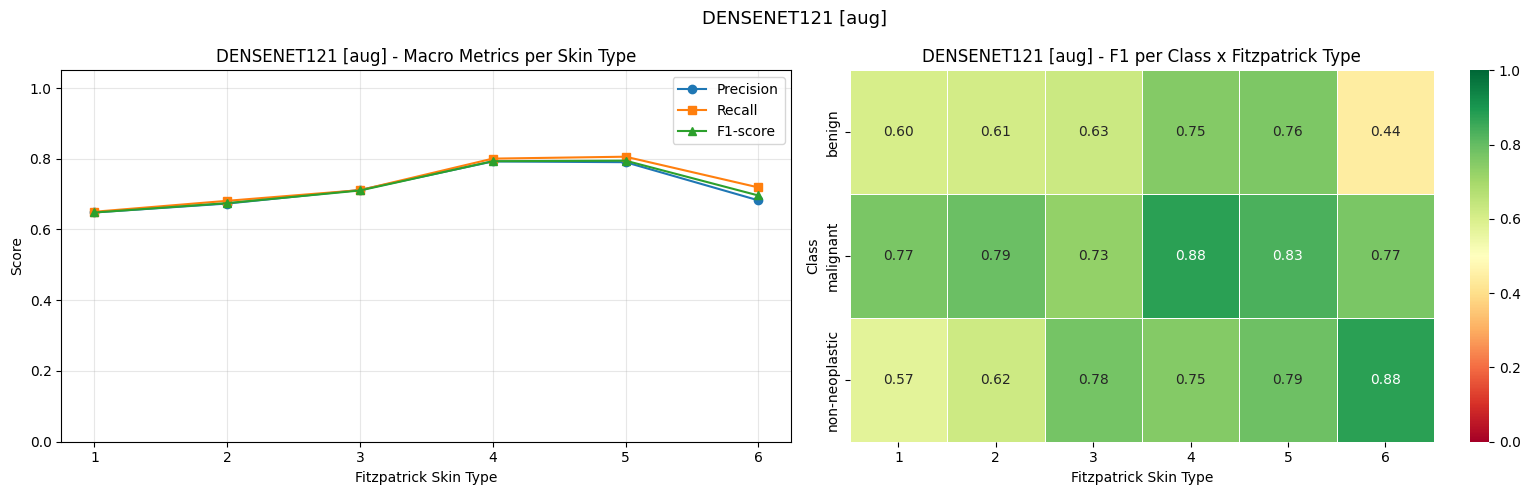

Saved: /kaggle/working//06_densenet121_aug_fairness.png

--- Fairness Report: VIT [aug] ---
  FST       N   Precision    Recall        F1
  FST 1  N=  160  Precision=0.5341  Recall=0.5241  F1=0.5245
  FST 2  N=  271  Precision=0.4772  Recall=0.4927  F1=0.4727
  FST 3  N=  189  Precision=0.5386  Recall=0.5405  F1=0.5370
  FST 4  N=  139  Precision=0.4939  Recall=0.4941  F1=0.4850
  FST 5  N=   76  Precision=0.6500  Recall=0.6558  F1=0.6348
  FST 6  N=   27  Precision=0.5111  Recall=0.4690  F1=0.4808


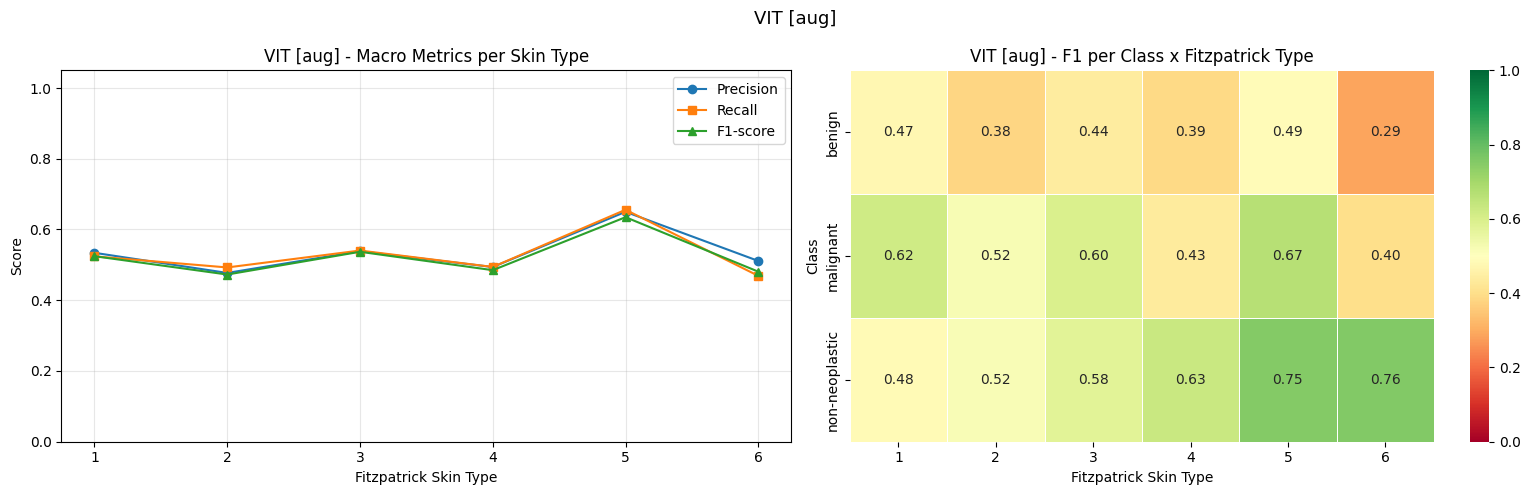

Saved: /kaggle/working//06_vit_aug_fairness.png


In [21]:
VALID_FST = [1, 2, 3, 4, 5, 6]


def fairness_report(y_true: np.ndarray, y_pred: np.ndarray,
                    fst: np.ndarray, title: str = "", save_prefix: str = ""):
    """
    Compute precision, recall, F1 per Fitzpatrick skin type and
    display a heatmap for each metric.
    """
    rows = []
    print(f"\n--- Fairness Report: {title} ---")
    print(f"{'FST':>5}  {'N':>6}  {'Precision':>10}  {'Recall':>8}  {'F1':>8}")

    for fst_val in VALID_FST:
        mask = fst == fst_val
        n = mask.sum()
        if n == 0:
            continue
        yt = y_true[mask]
        yp = y_pred[mask]
        p  = precision_score(yt, yp, average="macro", zero_division=0)
        r  = recall_score(yt,    yp, average="macro", zero_division=0)
        f  = f1_score(yt,        yp, average="macro", zero_division=0)
        rows.append({"FST": fst_val, "N": n,
                     "Precision": round(p, 4),
                     "Recall":    round(r, 4),
                     "F1-score":  round(f, 4)})
        print(f"  FST {fst_val}  N={n:5d}  Precision={p:.4f}  Recall={r:.4f}  F1={f:.4f}")

    fair_df = pd.DataFrame(rows)

    # Per-class breakdown per FST (F1)
    class_rows = []
    for fst_val in VALID_FST:
        mask = fst == fst_val
        if mask.sum() == 0:
            continue
        yt = y_true[mask]
        yp = y_pred[mask]
        for ci, cname in enumerate(CLASSES):
            cm_mask = (yt == ci)
            if cm_mask.sum() == 0:
                f1 = np.nan
            else:
                f1 = f1_score(yt, yp, labels=[ci], average="macro", zero_division=0)
            class_rows.append({"FST": fst_val, "Class": cname, "F1": f1})

    class_df = pd.DataFrame(class_rows)
    pivot    = class_df.pivot(index="Class", columns="FST", values="F1")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Macro metrics per FST
    x = fair_df["FST"].values
    axes[0].plot(x, fair_df["Precision"], marker="o", label="Precision")
    axes[0].plot(x, fair_df["Recall"],    marker="s", label="Recall")
    axes[0].plot(x, fair_df["F1-score"],  marker="^", label="F1-score")
    axes[0].set_xticks(x)
    axes[0].set_xlabel("Fitzpatrick Skin Type")
    axes[0].set_ylabel("Score")
    axes[0].set_title(f"{title} - Macro Metrics per Skin Type")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim(0, 1.05)

    # F1 heatmap (class x FST)
    sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn",
                linewidths=0.5, ax=axes[1],
                vmin=0, vmax=1)
    axes[1].set_title(f"{title} - F1 per Class x Fitzpatrick Type")
    axes[1].set_xlabel("Fitzpatrick Skin Type")
    axes[1].set_ylabel("Class")

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/{save_prefix}fairness.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

    # Save numerical tables
    fair_df.to_csv(f"{OUTPUT_DIR}/{save_prefix}fairness_macro.csv", index=False)
    class_df.to_csv(f"{OUTPUT_DIR}/{save_prefix}fairness_per_class.csv", index=False)
    return fair_df, class_df


# Run fairness analysis for ensemble results
for exp_name, res in ensemble_results.items():
    fairness_report(
        res["test_labels"], res["test_preds"], res["test_fst"],
        title=f"Ensemble [{exp_name}]",
        save_prefix=f"06_ensemble_{exp_name}_"
    )

# Also for each individual model (aug experiment)
if "aug" in test_results:
    for mname, res in test_results["aug"].items():
        fairness_report(
            res["labels"], res["preds"], res["fst"],
            title=f"{mname.upper()} [aug]",
            save_prefix=f"06_{mname}_aug_"
        )

---
## 14. Interpretability: UMAP of Learned Features

Fitting UMAP on 901 samples x 2048 dims ...


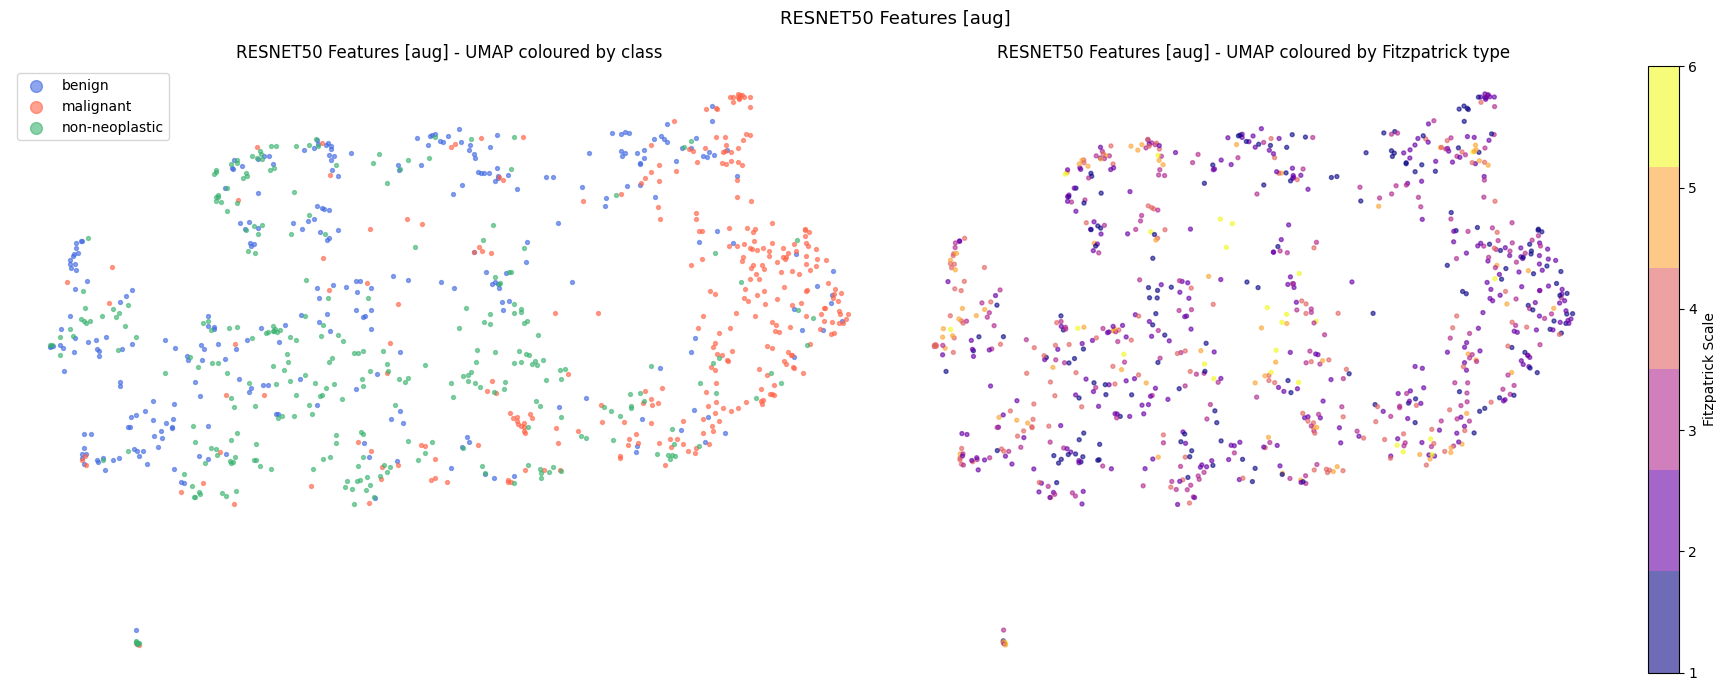

Saved: /kaggle/working//07_resnet50_umap.png
  resnet50: UMAP done.
Fitting UMAP on 901 samples x 1024 dims ...


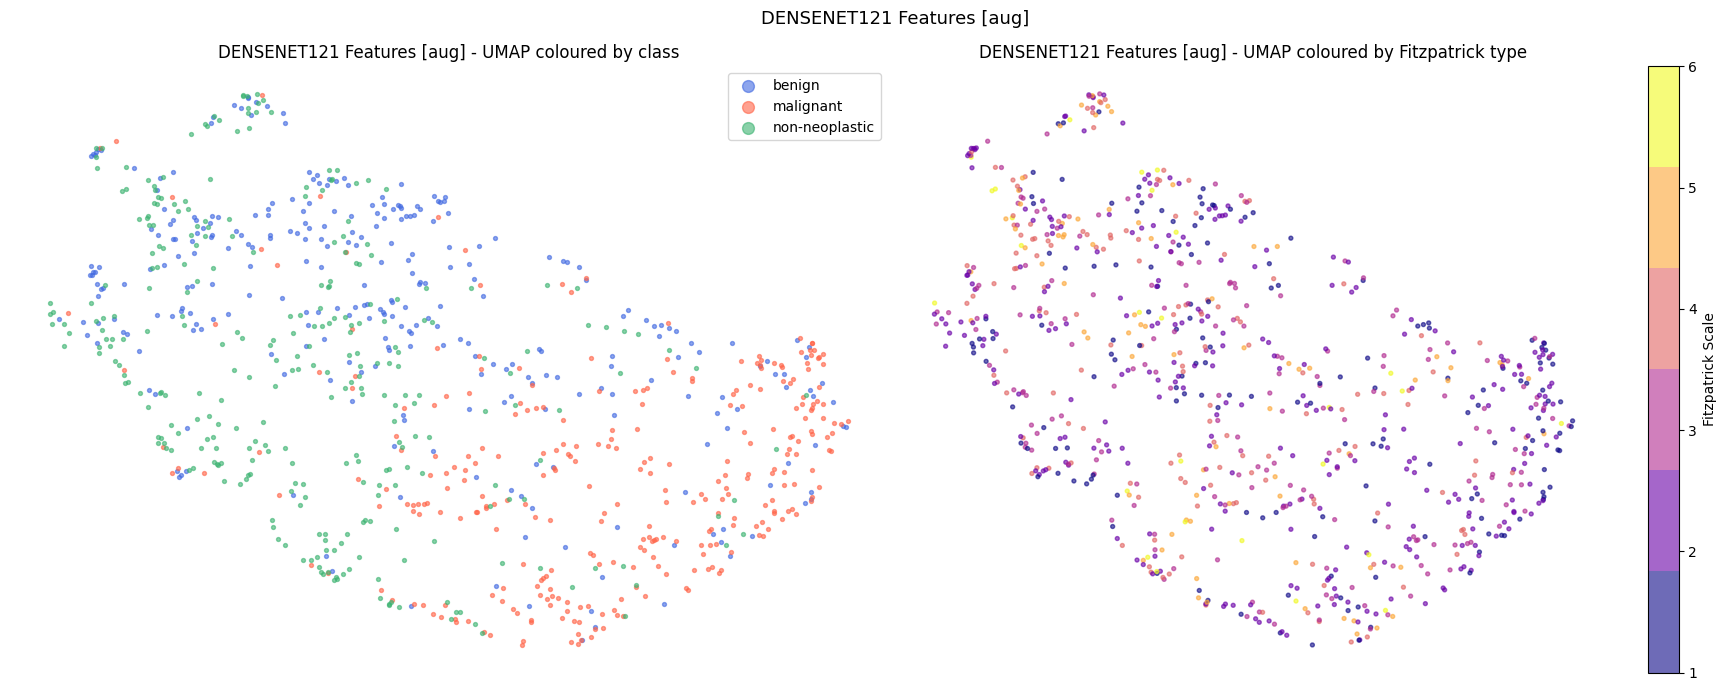

Saved: /kaggle/working//07_densenet121_umap.png
  densenet121: UMAP done.
Fitting UMAP on 901 samples x 768 dims ...


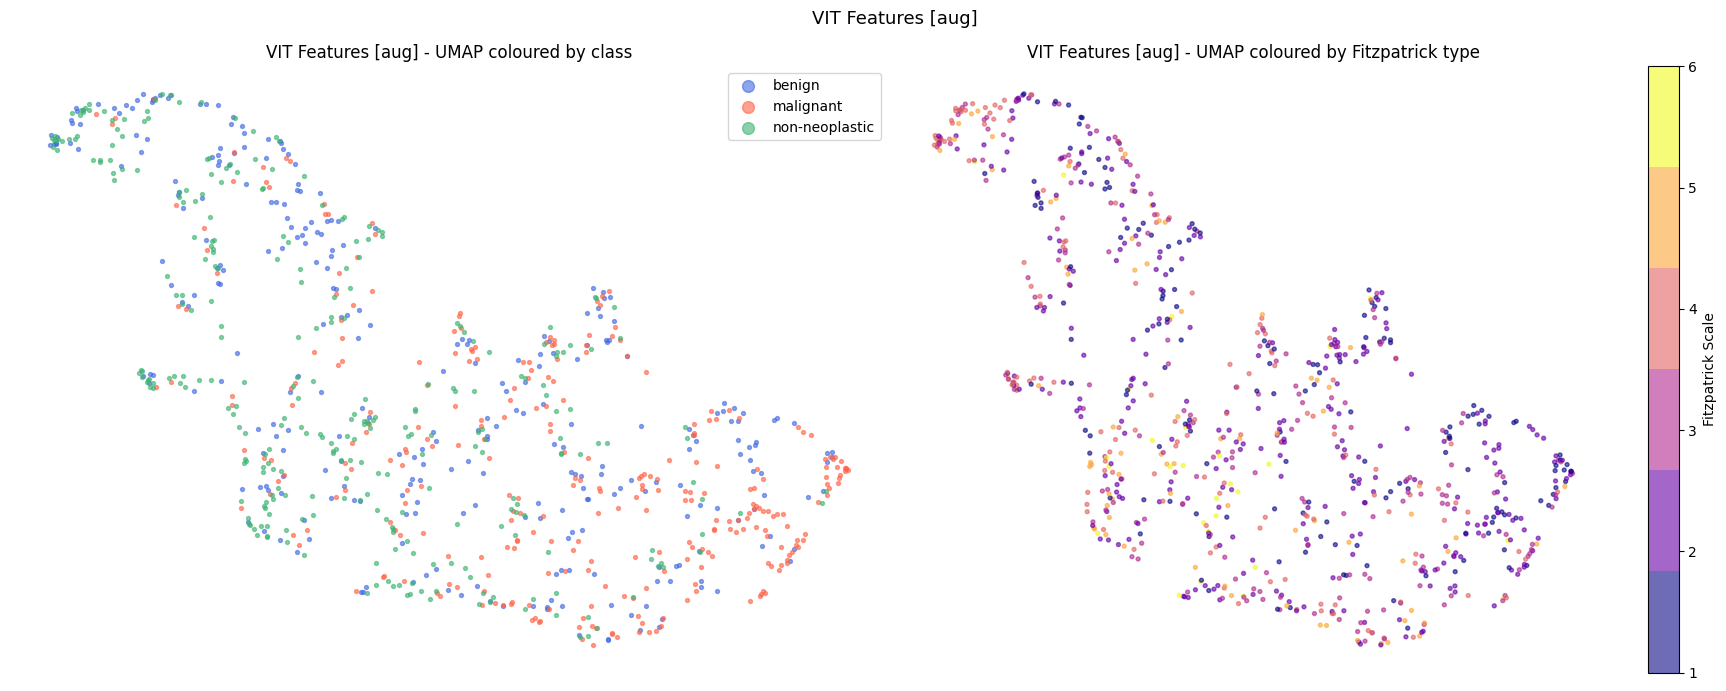

Saved: /kaggle/working//07_vit_umap.png
  vit: UMAP done.


In [22]:
def extract_features(model, loader, device, feature_hook_name: str = None) -> dict:
    """
    Extract penultimate-layer feature vectors and return them with labels.
    Works by removing the classification head and running a forward pass.
    """
    model.eval()
    features = []
    labels_out = []
    fst_out = []

    # Temporarily replace the head with Identity
    original_head = None
    if hasattr(model, "fc"):
        original_head = model.fc
        model.fc = nn.Identity()
    elif hasattr(model, "classifier"):
        original_head = model.classifier
        model.classifier = nn.Identity()
    elif hasattr(model, "head"):    # ViT
        original_head = model.head
        model.head = nn.Identity()

    with torch.no_grad():
        for images, label_batch, fst_batch in loader:
            images = images.to(device)
            out = model(images)
            # Some models return a tuple; take first element if so
            if isinstance(out, (tuple, list)):
                out = out[0]
            # DenseNet returns output from AdaptiveAvgPool2d: flatten if needed
            if out.dim() > 2:
                out = out.view(out.size(0), -1)
            features.append(out.cpu().numpy())
            labels_out.extend(label_batch.numpy())
            fst_out.extend(fst_batch.numpy())

    # Restore original head
    if original_head is not None:
        if hasattr(model, "fc"):
            model.fc = original_head
        elif hasattr(model, "classifier"):
            model.classifier = original_head
        elif hasattr(model, "head"):
            model.head = original_head

    return {
        "features": np.concatenate(features, axis=0),
        "labels":   np.array(labels_out),
        "fst":      np.array(fst_out),
    }


def plot_umap(features: np.ndarray, labels: np.ndarray,
              label_names: list, title: str = "",
              color_by_fst: bool = False, fst: np.ndarray = None,
              save_prefix: str = ""):
    """Fit UMAP and produce 2-D scatter plots coloured by class and by FST."""
    print(f"Fitting UMAP on {features.shape[0]} samples x {features.shape[1]} dims ...")
    reducer = umap.UMAP(
        n_neighbors=UMAP_N_NEIGHBORS,
        min_dist=UMAP_MIN_DIST,
        random_state=RANDOM_SEED,
        metric="cosine"
    )
    embedding = reducer.fit_transform(features)

    ncols = 2 if (color_by_fst and fst is not None) else 1
    fig, axes = plt.subplots(1, ncols, figsize=(9 * ncols, 7))
    if ncols == 1:
        axes = [axes]

    # Colour by class
    palette = ["royalblue", "tomato", "mediumseagreen"]
    for ci, (cname, colour) in enumerate(zip(label_names, palette)):
        mask = labels == ci
        axes[0].scatter(embedding[mask, 0], embedding[mask, 1],
                        c=colour, s=8, alpha=0.6, label=cname)
    axes[0].set_title(f"{title} - UMAP coloured by class")
    axes[0].legend(markerscale=3)
    axes[0].set_xlabel("UMAP-1")
    axes[0].set_ylabel("UMAP-2")
    axes[0].axis("off")

    # Colour by Fitzpatrick type
    if ncols == 2 and fst is not None:
        valid_mask = np.isin(fst, VALID_FST)
        fst_cmap   = plt.cm.get_cmap("plasma", 6)
        sc = axes[1].scatter(
            embedding[valid_mask, 0], embedding[valid_mask, 1],
            c=fst[valid_mask], cmap=fst_cmap, s=8, alpha=0.6,
            vmin=1, vmax=6
        )
        cbar = plt.colorbar(sc, ax=axes[1], ticks=VALID_FST)
        cbar.set_label("Fitzpatrick Scale")
        axes[1].set_title(f"{title} - UMAP coloured by Fitzpatrick type")
        axes[1].set_xlabel("UMAP-1")
        axes[1].set_ylabel("UMAP-2")
        axes[1].axis("off")

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/{save_prefix}umap.png"
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")
    return embedding


# Extract features and plot UMAP for each model (aug experiment)
umap_embeddings = {}
if trained_aug:
    for mname, model in trained_aug.items():
        feat_dict = extract_features(model, test_loader_aug, DEVICE)
        emb = plot_umap(
            feat_dict["features"], feat_dict["labels"],
            label_names=CLASSES,
            title=f"{mname.upper()} Features [aug]",
            color_by_fst=True, fst=feat_dict["fst"],
            save_prefix=f"07_{mname}_"
        )
        umap_embeddings[mname] = emb
        print(f"  {mname}: UMAP done.")

---
## 15. Interpretability: GradCAM Visualisations

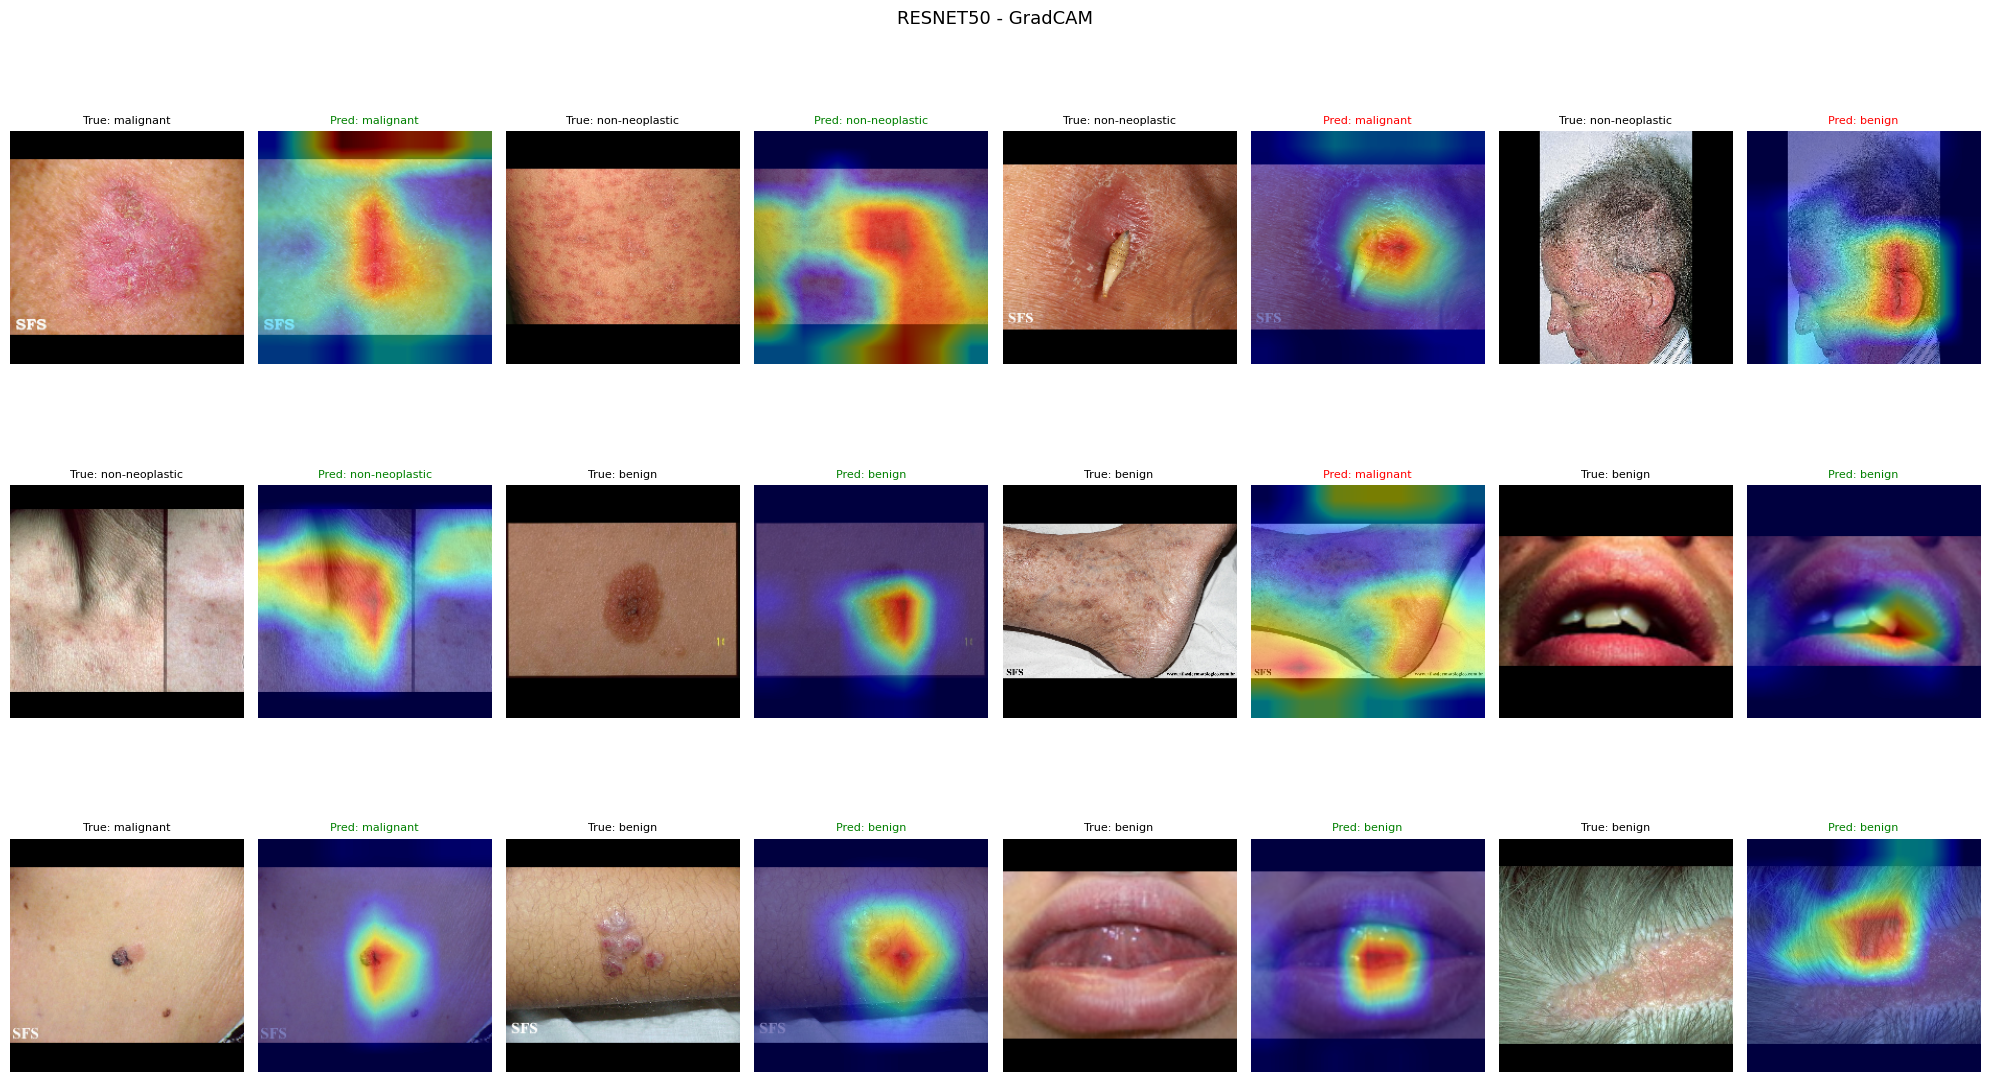

Saved: /kaggle/working//08_resnet50_aug_gradcam.png


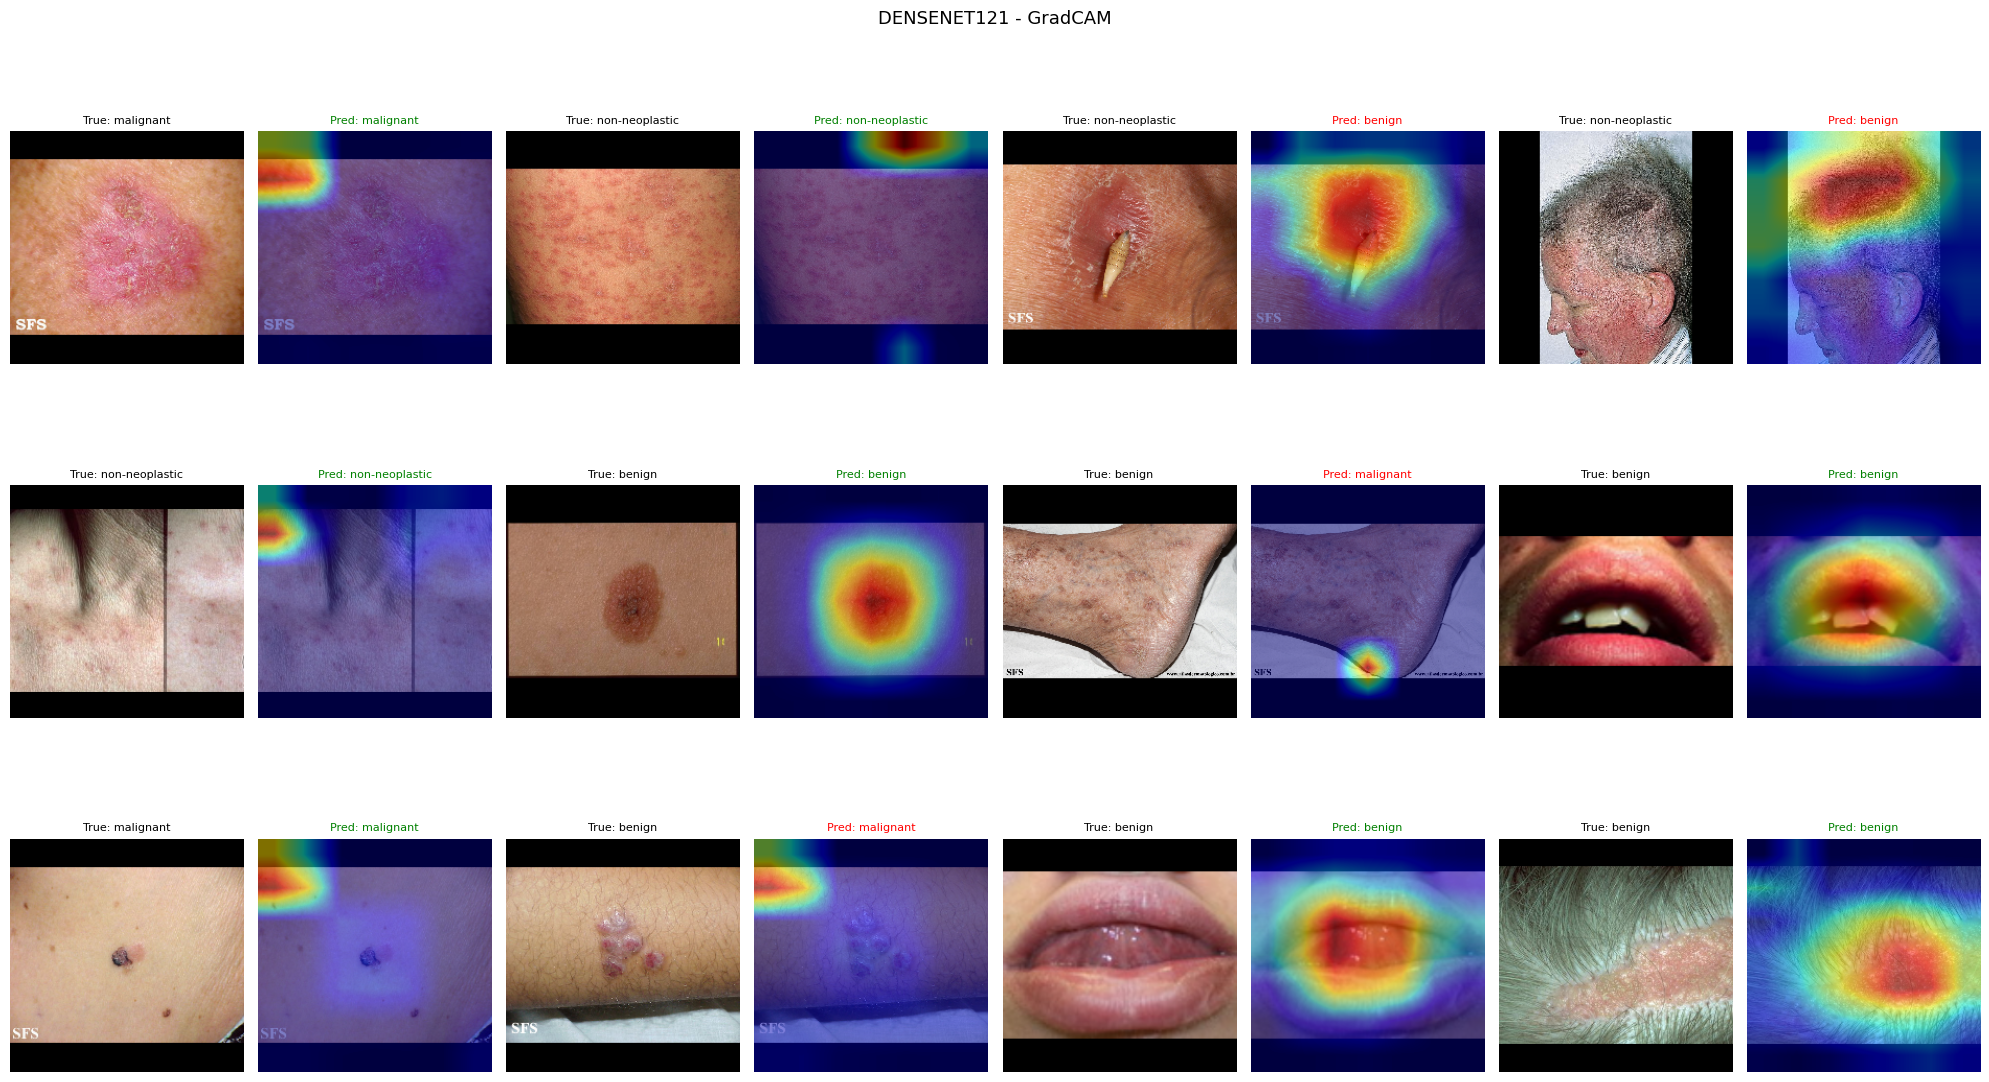

Saved: /kaggle/working//08_densenet121_aug_gradcam.png


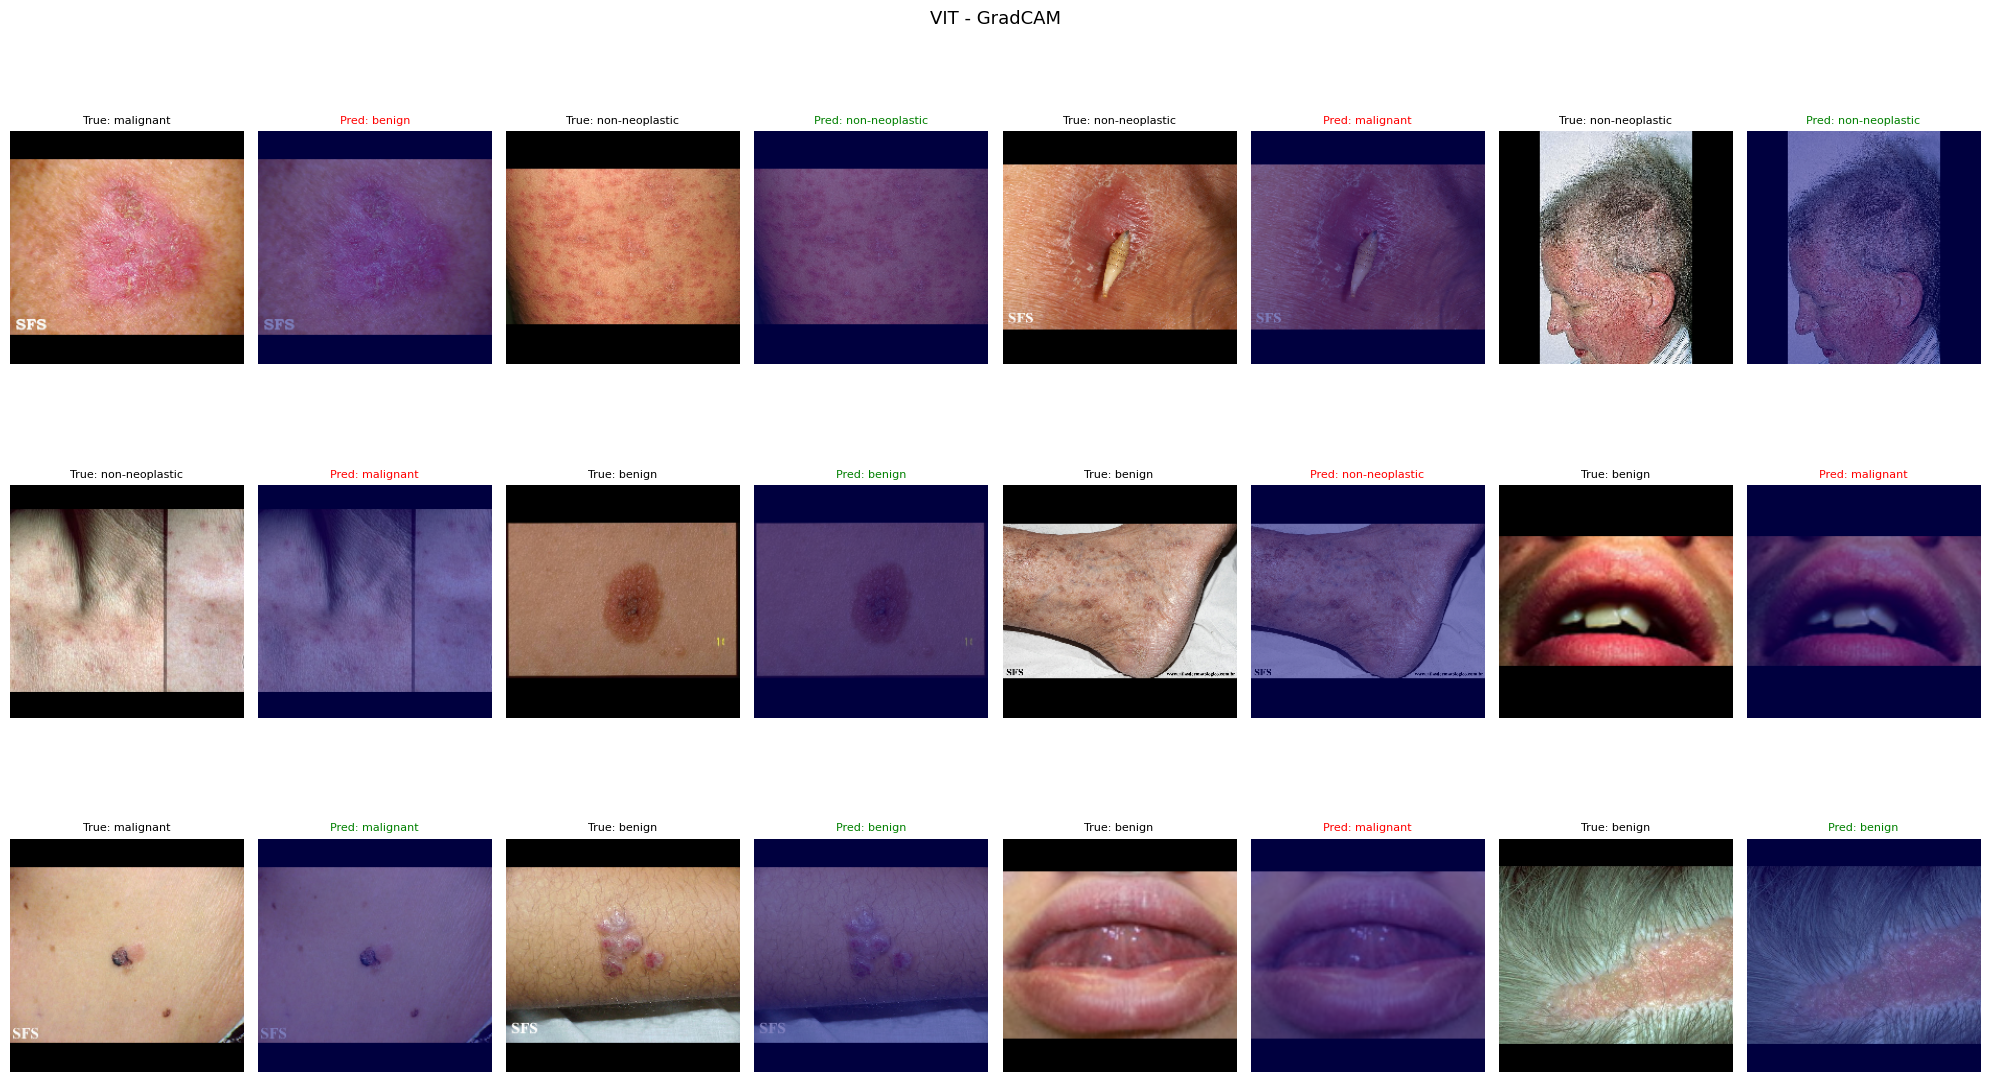

Saved: /kaggle/working//08_vit_aug_gradcam.png


In [24]:
# ── GradCAM implementation (no external dependency on grad-cam library) ───────
class GradCAM:
    """
    Gradient-weighted Class Activation Mapping.
    Hooks into a specified target convolutional layer.
    For ViT we use the last attention projection layer instead.
    """
    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self.gradients = None
        self.activations = None
        self._fw_hook = target_layer.register_forward_hook(self._fw_hook_fn)
        self._bw_hook = target_layer.register_full_backward_hook(self._bw_hook_fn)

    def _fw_hook_fn(self, module, input, output):
        self.activations = output.detach()

    def _bw_hook_fn(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor: torch.Tensor, class_idx: int = None) -> np.ndarray:
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()

        grads = self.gradients     # (1, C, H, W) or (1, tokens, dim)
        acts  = self.activations   # same

        # Handle both CNN feature maps and ViT token sequences
        if grads.dim() == 4:  # CNN
            pooled = grads.mean(dim=(2, 3), keepdim=True)   # (1, C, 1, 1)
            cam    = (pooled * acts).sum(dim=1).squeeze()    # (H, W)
        else:  # ViT: grads/acts are (1, num_tokens, dim)
            # Average over the token dimension
            pooled = grads.mean(dim=-1, keepdim=True)        # (1, T, 1)
            cam    = (pooled * acts).sum(dim=-1).squeeze()   # (T,)
            # Exclude CLS token and reshape to grid
            cam    = cam[1:]  # remove CLS
            grid   = int(cam.numel() ** 0.5)
            cam    = cam.reshape(grid, grid)

        cam = cam.cpu().numpy()
        cam = np.maximum(cam, 0)                              # ReLU
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

    def remove_hooks(self):
        self._fw_hook.remove()
        self._bw_hook.remove()


def get_target_layer(model, model_name: str):
    """Return the appropriate layer for GradCAM per model architecture."""
    if model_name == "resnet50":
        return model.layer4[-1].conv3
    elif model_name == "densenet121":
        return model.features.denseblock4.denselayer16.conv2
    elif model_name == "vit":
        # Last transformer block, attention projection
        return model.blocks[-1].attn.proj
    else:
        raise ValueError(f"Unknown model name: {model_name}")


def visualise_gradcam(
    model, model_name: str, loader,
    device, n_images: int = 12,
    save_prefix: str = ""
):
    """Show GradCAM overlays on randomly sampled test images."""
    target_layer = get_target_layer(model, model_name)
    gradcam      = GradCAM(model, target_layer)
    model.eval()

    # Collect a batch
    images_list, labels_list = [], []
    for imgs, labs, _ in loader:
        images_list.append(imgs)
        labels_list.append(labs)
        if sum(len(x) for x in images_list) >= n_images:
            break
    images_batch = torch.cat(images_list)[:n_images]
    labels_batch = torch.cat(labels_list)[:n_images].numpy()

    ncols = 4
    nrows = (n_images + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols * 2, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten()

    mean = np.array(IMAGENET_MEAN)
    std  = np.array(IMAGENET_STD)

    for i in range(n_images):
        img_tensor = images_batch[i:i+1].to(device)  # (1, 3, H, W)
        img_tensor.requires_grad_(False)
        cam = gradcam.generate(img_tensor.clone().requires_grad_(True))

        # Denormalise for display
        img_np = images_batch[i].permute(1, 2, 0).numpy()
        img_np = (img_np * std + mean).clip(0, 1)

        cam_resized = cv2.resize(cam, (img_np.shape[1], img_np.shape[0]))
        heatmap = plt.cm.jet(cam_resized)[..., :3]
        overlay = 0.5 * img_np + 0.5 * heatmap
        overlay = overlay.clip(0, 1)

        pred_label = CLASSES[img_tensor.to(device).detach()
                             .clone()
                             .requires_grad_(False)
                             .cpu()
                             .numpy()[0].argmax() if False else
                             model(img_tensor).argmax(dim=1).item()]
        true_label = CLASSES[labels_batch[i]]

        ax_img = axes[i * 2]
        ax_cam = axes[i * 2 + 1]

        ax_img.imshow(img_np)
        ax_img.axis("off")
        ax_img.set_title(f"True: {true_label}", fontsize=8)

        ax_cam.imshow(overlay)
        ax_cam.axis("off")
        colour = "green" if pred_label == true_label else "red"
        ax_cam.set_title(f"Pred: {pred_label}", fontsize=8, color=colour)

    # Hide unused axes
    for j in range(n_images * 2, len(axes)):
        axes[j].axis("off")

    plt.suptitle(f"{model_name.upper()} - GradCAM", fontsize=13)
    plt.tight_layout()
    path = f"{OUTPUT_DIR}/{save_prefix}gradcam.png"
    plt.savefig(path, dpi=130, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")
    gradcam.remove_hooks()


# Generate GradCAM for each model (aug experiment)
if trained_aug:
    for mname, model in trained_aug.items():
        visualise_gradcam(
            model, mname, test_loader_aug, DEVICE,
            n_images=N_GRADCAM_IMAGES,
            save_prefix=f"08_{mname}_aug_"
        )

---
## 16. Save Models, Configurations and Numerical Results

In [25]:
# ── Configuration JSON ────────────────────────────────────────────────────────
config = {
    "csv_path":           CSV_PATH,
    "img_dir":            IMG_DIR,
    "img_size":           IMG_SIZE,
    "samples_per_class":  SAMPLES_PER_CLASS,
    "random_seed":        RANDOM_SEED,
    "train_ratio":        TRAIN_RATIO,
    "val_ratio":          VAL_RATIO,
    "batch_size":         BATCH_SIZE,
    "num_epochs":         NUM_EPOCHS,
    "learning_rate":      LEARNING_RATE,
    "weight_decay":       WEIGHT_DECAY,
    "t0_cosine":          T_0,
    "t_mult_cosine":      T_MULT,
    "eta_min_cosine":     ETA_MIN,
    "focal_gamma":        FOCAL_GAMMA,
    "focal_alpha":        FOCAL_ALPHA,
    "classes":            CLASSES,
    "pretrained":         PRETRAINED,
    "ensemble_search":    ENSEMBLE_SEARCH,
    "grid_steps":         GRID_STEPS,
    "ensemble_weights": {
        exp: res["opt_weights"]
        for exp, res in ensemble_results.items()
    },
}

config_path = f"{OUTPUT_DIR}/config.json"
with open(config_path, "w") as f:
    json.dump(config, f, indent=2)
print(f"Configuration saved to {config_path}")

# ── Save all model weights ────────────────────────────────────────────────────
for exp_name, trained_dict in [("no_aug", trained_no_aug), ("aug", trained_aug)]:
    for mname, model in trained_dict.items():
        path = f"{OUTPUT_DIR}/{mname}_{exp_name}_final.pth"
        torch.save({
            "model_state_dict": model.state_dict(),
            "model_name":       mname,
            "num_classes":      NUM_CLASSES,
            "classes":          CLASSES,
            "img_size":         IMG_SIZE,
            "experiment":       exp_name,
        }, path)
        print(f"  Saved: {path}")

print("\nAll models and configuration saved.")

Configuration saved to /kaggle/working//config.json
  Saved: /kaggle/working//resnet50_no_aug_final.pth
  Saved: /kaggle/working//densenet121_no_aug_final.pth
  Saved: /kaggle/working//vit_no_aug_final.pth
  Saved: /kaggle/working//resnet50_aug_final.pth
  Saved: /kaggle/working//densenet121_aug_final.pth
  Saved: /kaggle/working//vit_aug_final.pth

All models and configuration saved.


In [26]:
# ──  how to reload a saved model ─────────────────────────────────────
# checkpoint = torch.load(f"{OUTPUT_DIR}/resnet50_aug_final.pth", map_location=DEVICE)
# model = MODEL_BUILDERS[checkpoint["model_name"]](
#     checkpoint["num_classes"], pretrained=False
# )
# model.load_state_dict(checkpoint["model_state_dict"])
# model.to(DEVICE).eval()
# print("Model reloaded successfully.")

---
## 17. Final Consolidated Results

In [3]:
print("="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)

print("\n[A] Individual Model Test Performance")
print(summary_df.to_string(index=False))

print("\n[B] Ensemble Test Performance")
ens_rows = []
for exp_name, res in ensemble_results.items():
    y_true = res["test_labels"]
    y_pred = res["test_preds"]
    ens_rows.append({
        "Experiment":   exp_name,
        "Weights":      res["opt_weights"],
        "Macro P":      round(precision_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Macro R":      round(recall_score(y_true, y_pred, average="macro", zero_division=0), 4),
        "Macro F1":     round(f1_score(y_true, y_pred, average="macro", zero_division=0), 4),
    })
ens_df = pd.DataFrame(ens_rows)
print(ens_df.to_string(index=False))

ens_df.to_csv(f"{OUTPUT_DIR}/09_ensemble_final_summary.csv", index=False)
print(f"\nAll numerical results saved in {OUTPUT_DIR}/")
print("\nFiles overview:")
for p in sorted(Path(OUTPUT_DIR).iterdir()):
    print(f"  {p.name}")

FINAL RESULTS SUMMARY

[A] Individual Model Test Performance


NameError: name 'summary_df' is not defined